# Ablation Analysis: Imbalanced Scenes (ablation_imbalanced_sanity_v1)

This notebook parses training/eval artifacts under `OUTPUT_ROOT` to:
- Compare image-quality metrics (PSNR/SSIM/LPIPS) per scene and imbalance ratio.
- Inspect learning curves / losses (best-effort from `console_log.txt`, with fallback to `metrics_history.json`).
- Analyze camera selection behavior using `selection_history.jsonl` and `cameras.json` (entropy/Gini/top-k share, dup vs non-dup selection).

All paths and outputs are local to this workspace.

In [1]:
from __future__ import annotations

import json
import math
import os
import re
import warnings
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np

# Optional deps
try:
    import pandas as pd
except Exception as e:
    pd = None
    _pandas_import_error = e

try:
    import matplotlib.pyplot as plt
except Exception as e:
    plt = None
    _plt_import_error = e

try:
    import seaborn as sns
except Exception:
    sns = None

# -----------------
# 1) Configure paths
# -----------------
OUTPUT_ROOT = Path("/home/fgrob/gaussian-splatting/output/ablation_imbalanced_sanity_v1")
REPO_ROOT = OUTPUT_ROOT.parents[1]  # .../gaussian-splatting
CACHE_DIR = REPO_ROOT / ".cache_eval"
NOTEBOOK_OUTPUTS_DIR = REPO_ROOT / "notebook_outputs" / "ablation_imbalanced_sanity_v1_analysis"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

if pd is None:
    raise RuntimeError(
        "pandas is required for this notebook. "
        "Install it in your current env, e.g. `pip install pandas seaborn`.\n\n"
        f"Original import error: {_pandas_import_error}"
    )

if plt is None:
    raise RuntimeError(
        "matplotlib is required for this notebook. "
        "Install it in your current env, e.g. `pip install matplotlib`.\n\n"
        f"Original import error: {_plt_import_error}"
    )

if sns is not None:
    sns.set_context("talk")


def read_json(path: Path) -> Any:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def read_jsonl(path: Path) -> Iterable[dict]:
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            yield json.loads(line)


def savefig(name: str) -> Path:
    out = NOTEBOOK_OUTPUTS_DIR / name
    plt.tight_layout()
    plt.savefig(out, dpi=200)
    return out


def parse_scene_name(scene_name: str) -> Tuple[str, Optional[int], Optional[int]]:
    """Parse e.g. 0c5385e84b_imb20_rand1 -> (base, 20, 1)."""
    m = re.match(r"^(?P<base>[^_]+)_imb(?P<ratio>\d+)_rand(?P<rand>\d+)$", scene_name)
    if not m:
        return scene_name, None, None
    return m.group("base"), int(m.group("ratio")), int(m.group("rand"))


@dataclass(frozen=True)
class RunRef:
    method: str
    scene: str
    base_scene_id: str
    ratio: Optional[int]
    rand_id: Optional[int]
    seed: int
    run_dir: Path


print("CWD:", Path.cwd())
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("Outputs ->", NOTEBOOK_OUTPUTS_DIR.resolve())

CWD: /home/fgrob/gaussian-splatting/notebooks
OUTPUT_ROOT: /home/fgrob/gaussian-splatting/output/ablation_imbalanced_sanity_v1
Outputs -> /home/fgrob/gaussian-splatting/notebook_outputs/ablation_imbalanced_sanity_v1_analysis


## 2. Discover runs (methods × scenes × imbalance ratios × seeds)

We walk `OUTPUT_ROOT` and build a run registry keyed by `(method, scene, ratio, seed)`.

Expected structure:
- `OUTPUT_ROOT/<method>/<scene_name>/seed_<n>/...`

In [2]:
def discover_runs(output_root: Path) -> List[RunRef]:
    runs: List[RunRef] = []
    if not output_root.exists():
        raise FileNotFoundError(f"OUTPUT_ROOT not found: {output_root}")

    for method_dir in sorted(output_root.iterdir()):
        if not method_dir.is_dir():
            continue
        if method_dir.name == "logs":
            continue

        for scene_dir in sorted(method_dir.iterdir()):
            if not scene_dir.is_dir():
                continue
            base_scene_id, ratio, rand_id = parse_scene_name(scene_dir.name)

            seed_dirs = sorted([p for p in scene_dir.iterdir() if p.is_dir() and p.name.startswith("seed_")])
            if not seed_dirs:
                warnings.warn(f"No seed dirs in: {scene_dir}")
                continue

            for seed_dir in seed_dirs:
                m = re.match(r"seed_(\d+)$", seed_dir.name)
                if not m:
                    continue
                seed = int(m.group(1))
                runs.append(
                    RunRef(
                        method=method_dir.name,
                        scene=scene_dir.name,
                        base_scene_id=base_scene_id,
                        ratio=ratio,
                        rand_id=rand_id,
                        seed=seed,
                        run_dir=seed_dir,
                    )
                )

    return runs


runs = discover_runs(OUTPUT_ROOT)
print(f"Discovered {len(runs)} runs")

run_registry = pd.DataFrame(
    [
        {
            "method": r.method,
            "scene": r.scene,
            "base_scene_id": r.base_scene_id,
            "ratio": r.ratio,
            "rand_id": r.rand_id,
            "seed": r.seed,
            "run_dir": str(r.run_dir),
        }
        for r in runs
    ]
)

run_registry = run_registry.sort_values(["method", "base_scene_id", "ratio", "seed"]).reset_index(drop=True)
run_registry.head(10)

Discovered 54 runs


,method,scene,base_scene_id,ratio,rand_id,seed,run_dir
0,B1,0c5385e84b_imb20_rand1,0c5385e84b,20,1,0,/home/fgrob/gaussian-splatting/output/ablation...
1,B1,0c5385e84b_imb40_rand1,0c5385e84b,40,1,0,/home/fgrob/gaussian-splatting/output/ablation...
2,B1,0c5385e84b_imb60_rand1,0c5385e84b,60,1,0,/home/fgrob/gaussian-splatting/output/ablation...
3,B1,5371eff4f9_imb20_rand1,5371eff4f9,20,1,0,/home/fgrob/gaussian-splatting/output/ablation...
4,B1,5371eff4f9_imb40_rand1,5371eff4f9,40,1,0,/home/fgrob/gaussian-splatting/output/ablation...
5,B1,5371eff4f9_imb60_rand1,5371eff4f9,60,1,0,/home/fgrob/gaussian-splatting/output/ablation...
6,B1,c0f5742640_imb20_rand1,c0f5742640,20,1,0,/home/fgrob/gaussian-splatting/output/ablation...
7,B1,c0f5742640_imb40_rand1,c0f5742640,40,1,0,/home/fgrob/gaussian-splatting/output/ablation...
8,B1,c0f5742640_imb60_rand1,c0f5742640,60,1,0,/home/fgrob/gaussian-splatting/output/ablation...
9,B2,0c5385e84b_imb20_rand1,0c5385e84b,20,1,0,/home/fgrob/gaussian-splatting/output/ablation...


In [3]:
# Quick structure validation
counts = (
    run_registry.groupby(["method", "base_scene_id", "ratio"])["seed"].nunique().reset_index(name="num_seeds")
)
print("Run counts (num seeds) per method/scene/ratio:")
display(counts.pivot_table(index=["base_scene_id", "ratio"], columns="method", values="num_seeds", fill_value=0))

# Save registry
run_registry_path = NOTEBOOK_OUTPUTS_DIR / "run_registry.csv"
run_registry.to_csv(run_registry_path, index=False)
print("Wrote:", run_registry_path.resolve())

Run counts (num seeds) per method/scene/ratio:


method                B1   B2   CL   S1   S2   S3
base_scene_id ratio                              
0c5385e84b    20     1.0  1.0  1.0  1.0  1.0  1.0
              40     1.0  1.0  1.0  1.0  1.0  1.0
              60     1.0  1.0  1.0  1.0  1.0  1.0
5371eff4f9    20     1.0  1.0  1.0  1.0  1.0  1.0
              40     1.0  1.0  1.0  1.0  1.0  1.0
              60     1.0  1.0  1.0  1.0  1.0  1.0
c0f5742640    20     1.0  1.0  1.0  1.0  1.0  1.0
              40     1.0  1.0  1.0  1.0  1.0  1.0
              60     1.0  1.0  1.0  1.0  1.0  1.0

Wrote: /home/fgrob/gaussian-splatting/notebook_outputs/ablation_imbalanced_sanity_v1_analysis/run_registry.csv


## 3. Parse console logs for losses / learning curves (best-effort)

We attempt to extract losses from `console_log.txt` using a few regex patterns. If no matches are found, we fall back to `metrics_history.json` (train/test L1 over time).

In [4]:
LOSS_PATTERNS = [
    # Examples these try to match (vary across repos):
    # "Iter 100 Loss: 0.123" / "[100] loss=0.123" / "iteration=100 ... loss 0.123"
    re.compile(r"(?:^|\b)(?:iter|iteration)\s*[:=]?\s*(\d+).{0,80}?(?:loss|total_loss)\s*[:=]?\s*([0-9]*\.?[0-9]+(?:e[-+]?\d+)?)", re.IGNORECASE),
    re.compile(r"\[(\d+)\].{0,80}?(?:loss|total_loss)\s*[:=]?\s*([0-9]*\.?[0-9]+(?:e[-+]?\d+)?)", re.IGNORECASE),
]


def parse_console_losses(console_log: Path) -> pd.DataFrame:
    rows = []
    if not console_log.exists():
        return pd.DataFrame(columns=["iteration", "key", "value"])

    with console_log.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            for pat in LOSS_PATTERNS:
                m = pat.search(line)
                if m:
                    it = int(m.group(1))
                    val = float(m.group(2))
                    rows.append({"iteration": it, "key": "loss", "value": val})
                    break

    return pd.DataFrame(rows)


def load_metrics_history(run_dir: Path) -> Optional[List[dict]]:
    p = run_dir / "metrics_history.json"
    if not p.exists():
        return None
    try:
        data = read_json(p)
    except Exception as e:
        warnings.warn(f"Failed to read {p}: {e}")
        return None
    if not isinstance(data, list):
        warnings.warn(f"Unexpected metrics_history schema in {p}")
        return None
    return data


def metrics_history_to_loss_df(history: List[dict]) -> pd.DataFrame:
    rows = []
    for rec in history:
        it = rec.get("iteration")
        if it is None:
            continue
        for split in ["train", "test"]:
            metrics = rec.get(split)
            if not isinstance(metrics, dict):
                continue
            # Repo uses 'L1' as a proxy for loss.
            if "L1" in metrics:
                rows.append({"iteration": int(it), "key": f"{split}.L1", "value": float(metrics["L1"])})
    return pd.DataFrame(rows)


loss_rows = []
for r in runs:
    console_df = parse_console_losses(r.run_dir / "console_log.txt")
    if len(console_df) > 0:
        src = "console_log"
        use_df = console_df
    else:
        hist = load_metrics_history(r.run_dir)
        use_df = metrics_history_to_loss_df(hist) if hist else pd.DataFrame(columns=["iteration", "key", "value"])
        src = "metrics_history"

    if len(use_df) == 0:
        continue

    use_df = use_df.copy()
    use_df["method"] = r.method
    use_df["scene"] = r.scene
    use_df["base_scene_id"] = r.base_scene_id
    use_df["ratio"] = r.ratio
    use_df["seed"] = r.seed
    use_df["source"] = src
    loss_rows.append(use_df)

loss_df = pd.concat(loss_rows, ignore_index=True) if loss_rows else pd.DataFrame()
print("Loss rows:", len(loss_df))
loss_df.head()

Loss rows: 3348


,iteration,key,value,method,scene,base_scene_id,ratio,seed,source
0,100,train.L1,0.155813,B1,0c5385e84b_imb20_rand1,0c5385e84b,20,0,metrics_history
1,100,test.L1,0.174046,B1,0c5385e84b_imb20_rand1,0c5385e84b,20,0,metrics_history
2,200,train.L1,0.107189,B1,0c5385e84b_imb20_rand1,0c5385e84b,20,0,metrics_history
3,200,test.L1,0.130507,B1,0c5385e84b_imb20_rand1,0c5385e84b,20,0,metrics_history
4,300,train.L1,0.091653,B1,0c5385e84b_imb20_rand1,0c5385e84b,20,0,metrics_history


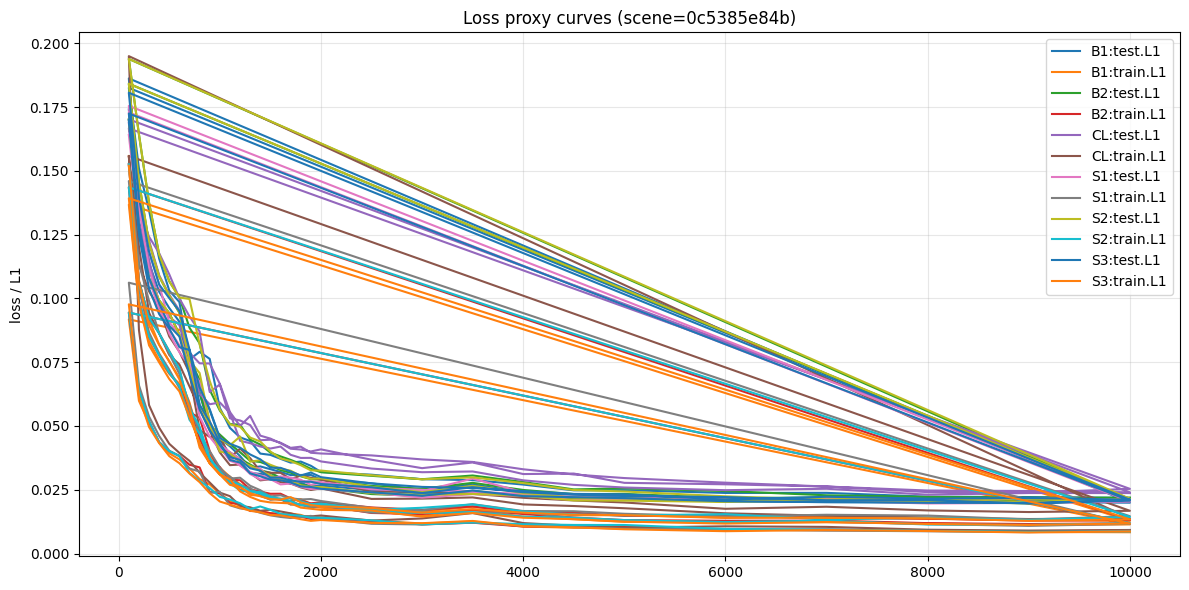

In [5]:
# Plot loss curves for a selected scene
SELECT_SCENE = run_registry["base_scene_id"].iloc[0] if len(run_registry) else None

if SELECT_SCENE is not None and len(loss_df) > 0:
    dfp = loss_df[(loss_df["base_scene_id"] == SELECT_SCENE) & (loss_df["key"].isin(["train.L1", "test.L1", "loss"]))].copy()
    if len(dfp) == 0:
        print("No loss data found for", SELECT_SCENE)
    else:
        plt.figure(figsize=(12, 6))
        sns_line = sns.lineplot if sns is not None else None
        if sns_line is not None:
            sns.lineplot(data=dfp, x="iteration", y="value", hue="method", style="key")
        else:
            for (method, key), g in dfp.groupby(["method", "key"]):
                plt.plot(g["iteration"], g["value"], label=f"{method}:{key}")
            plt.legend()
        plt.title(f"Loss proxy curves (scene={SELECT_SCENE})")
        plt.ylabel("loss / L1")
        plt.grid(True, alpha=0.3)
        savefig(f"loss_curves_{SELECT_SCENE}.png")
        plt.show()
else:
    print("No loss_df available (missing logs/metrics_history?)")

## 4. Load per-run metrics (PSNR/SSIM/LPIPS) from eval artifacts

Primary sources in this ablation:
- `final_results.json` (mean_psnr/mean_ssim/mean_lpips)
- `metrics_history.json` (per-iteration train/test metrics)

We standardize everything into a per-run metrics table.

In [6]:
def load_final_results(run_dir: Path) -> Dict[str, float]:
    p = run_dir / "final_results.json"
    if not p.exists():
        return {}
    data = read_json(p)
    if not isinstance(data, dict):
        return {}
    out = {}
    for k in ["mean_psnr", "mean_ssim", "mean_lpips"]:
        if k in data:
            out[k] = float(data[k])
    return out


def _best_final(vals: List[float], mode: str) -> Dict[str, float]:
    if not vals:
        return {}
    if mode == "max":
        best = float(np.max(vals))
    elif mode == "min":
        best = float(np.min(vals))
    else:
        raise ValueError(f"Unknown mode: {mode}")
    return {"best": best, "final": float(vals[-1])}


def summarize_metrics_history(history: Optional[List[dict]]) -> Dict[str, float]:
    """Summarize train/test curves from metrics_history.json.

    Adds columns like best_test_psnr/final_test_psnr and best_train_psnr/final_train_psnr.
    """
    if not history:
        return {}

    out: Dict[str, float] = {}
    # mode per metric: PSNR/SSIM maximize; LPIPS/L1 minimize
    metric_modes = {"PSNR": "max", "SSIM": "max", "LPIPS": "min", "L1": "min"}
    for split in ("train", "test"):
        by_metric: Dict[str, List[float]] = {k: [] for k in metric_modes}
        for rec in history:
            m = rec.get(split)
            if not isinstance(m, dict):
                continue
            for metric, mode in metric_modes.items():
                if metric in m:
                    try:
                        by_metric[metric].append(float(m[metric]))
                    except Exception:
                        pass
        for metric, mode in metric_modes.items():
            vals = by_metric.get(metric, [])
            if not vals:
                continue
            bf = _best_final(vals, mode)
            key_base = f"{split}_{metric.lower()}"
            out[f"best_{key_base}"] = bf["best"]
            out[f"final_{key_base}"] = bf["final"]

    return out


def load_split_summary(run_dir: Path) -> Dict[str, Any]:
    p = run_dir / "split_summary.json"
    if not p.exists():
        return {}
    data = read_json(p)
    if not isinstance(data, dict):
        return {}
    # Keep it small
    out = {k: data.get(k) for k in ["num_total", "num_train", "num_test", "split_method"] if k in data}
    return out


metric_rows = []
for r in runs:
    hist = load_metrics_history(r.run_dir)
    row = {
        "method": r.method,
        "scene": r.scene,
        "base_scene_id": r.base_scene_id,
        "ratio": r.ratio,
        "rand_id": r.rand_id,
        "seed": r.seed,
        "run_dir": str(r.run_dir),
    }
    row.update(load_final_results(r.run_dir))
    row.update(summarize_metrics_history(hist))
    row.update(load_split_summary(r.run_dir))
    metric_rows.append(row)

metrics_per_run = pd.DataFrame(metric_rows)
metrics_per_run.head()

,method,scene,base_scene_id,ratio,rand_id,seed,run_dir,mean_psnr,mean_ssim,mean_lpips,...,best_test_ssim,final_test_ssim,best_test_lpips,final_test_lpips,best_test_l1,final_test_l1,num_total,num_train,num_test,split_method
0,B1,0c5385e84b_imb20_rand1,0c5385e84b,20,1,0,/home/fgrob/gaussian-splatting/output/ablation...,28.991044,0.916927,0.196999,...,0.917310,0.917310,0.196702,0.196702,0.019948,0.019948,220,210,10,nerfstudio_test_frames
1,B1,0c5385e84b_imb40_rand1,0c5385e84b,40,1,0,/home/fgrob/gaussian-splatting/output/ablation...,28.175883,0.909106,0.206878,...,0.912529,0.909859,0.203883,0.206441,0.020652,0.021407,294,284,10,nerfstudio_test_frames
2,B1,0c5385e84b_imb60_rand1,0c5385e84b,60,1,0,/home/fgrob/gaussian-splatting/output/ablation...,27.924447,0.902470,0.217512,...,0.904126,0.904126,0.216484,0.216484,0.021818,0.021818,440,430,10,nerfstudio_test_frames
3,B1,5371eff4f9_imb20_rand1,5371eff4f9,20,1,0,/home/fgrob/gaussian-splatting/output/ablation...,29.651240,0.925555,0.252765,...,0.925894,0.925894,0.252559,0.252559,0.020078,0.020366,298,288,10,nerfstudio_test_frames
4,B1,5371eff4f9_imb40_rand1,5371eff4f9,40,1,0,/home/fgrob/gaussian-splatting/output/ablation...,29.326021,0.922464,0.269953,...,0.922698,0.922698,0.269806,0.269806,0.020713,0.021154,397,387,10,nerfstudio_test_frames


Wrote: /home/fgrob/gaussian-splatting/notebook_outputs/ablation_imbalanced_sanity_v1_analysis/metrics_per_run.csv


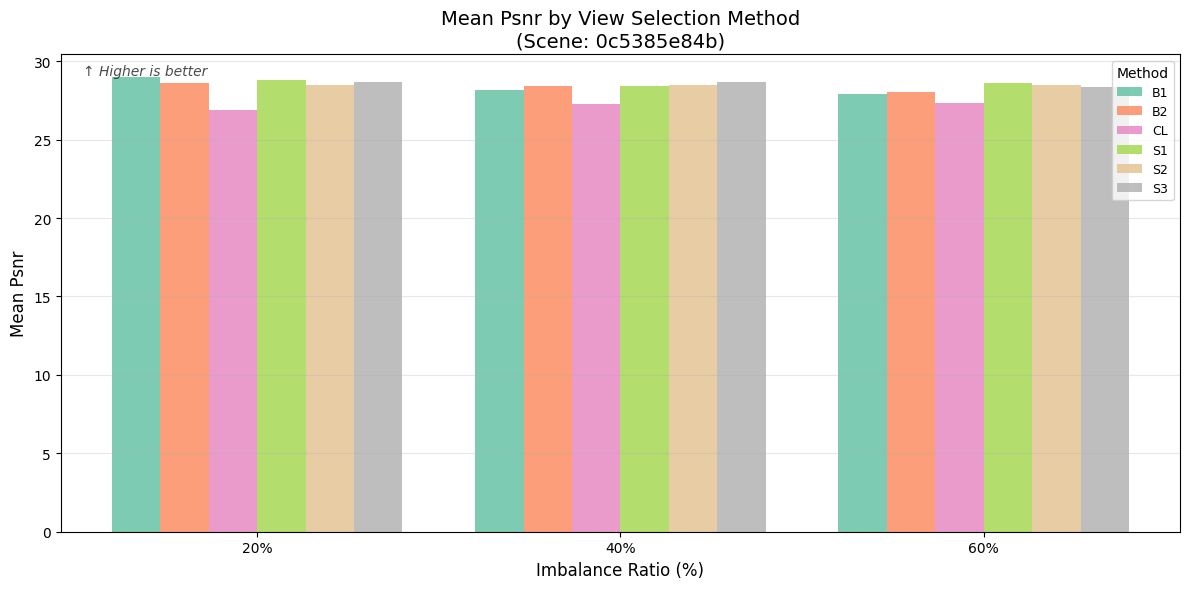

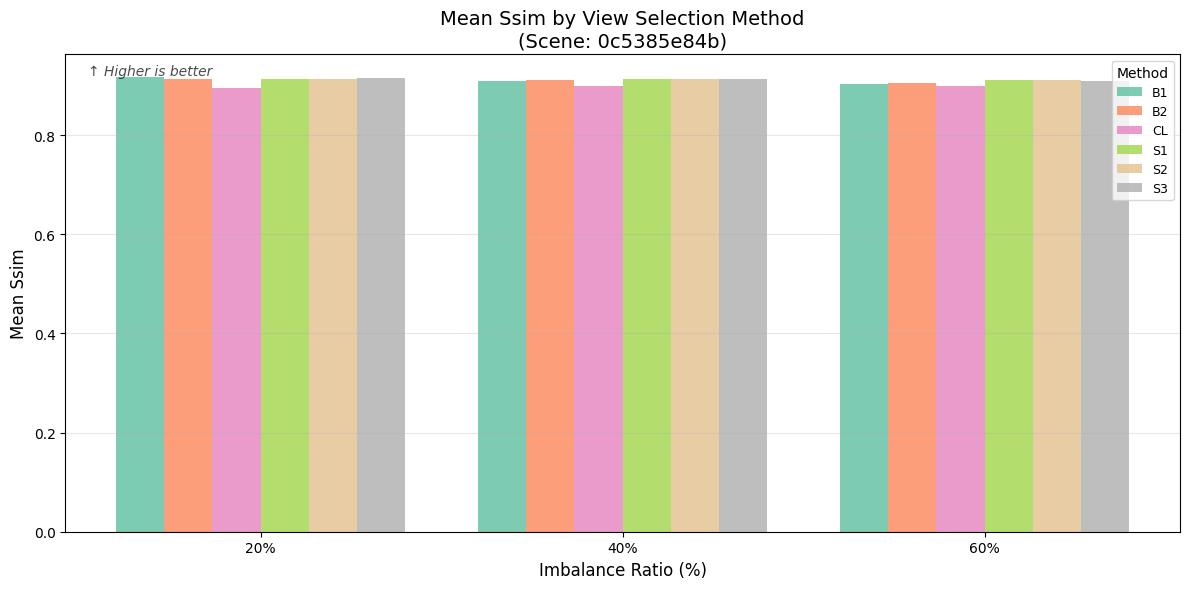

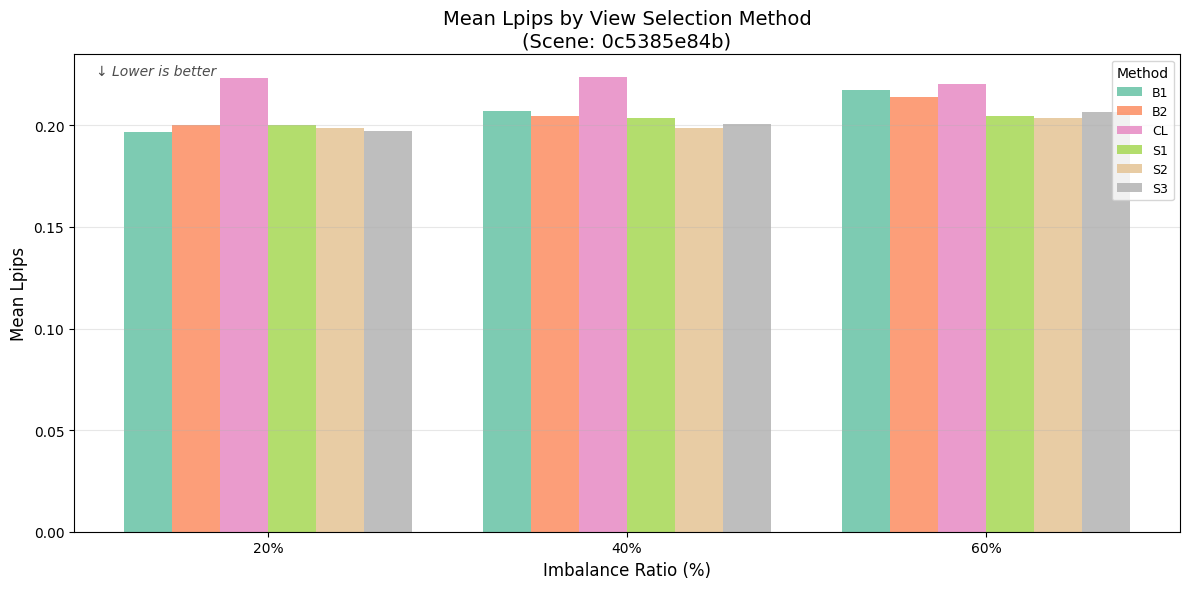

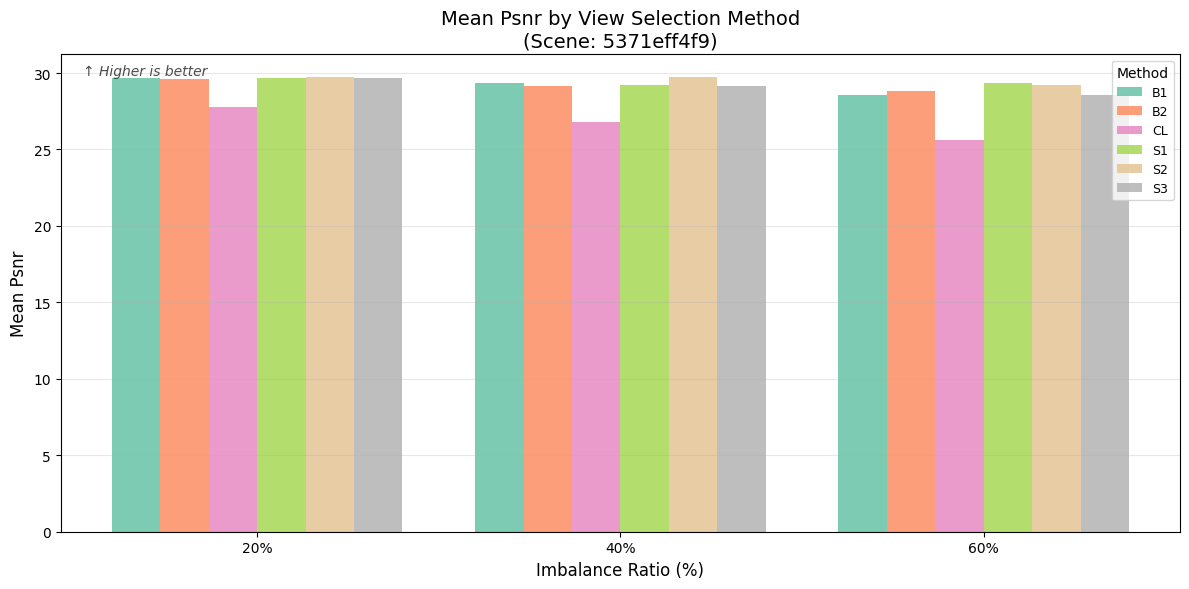

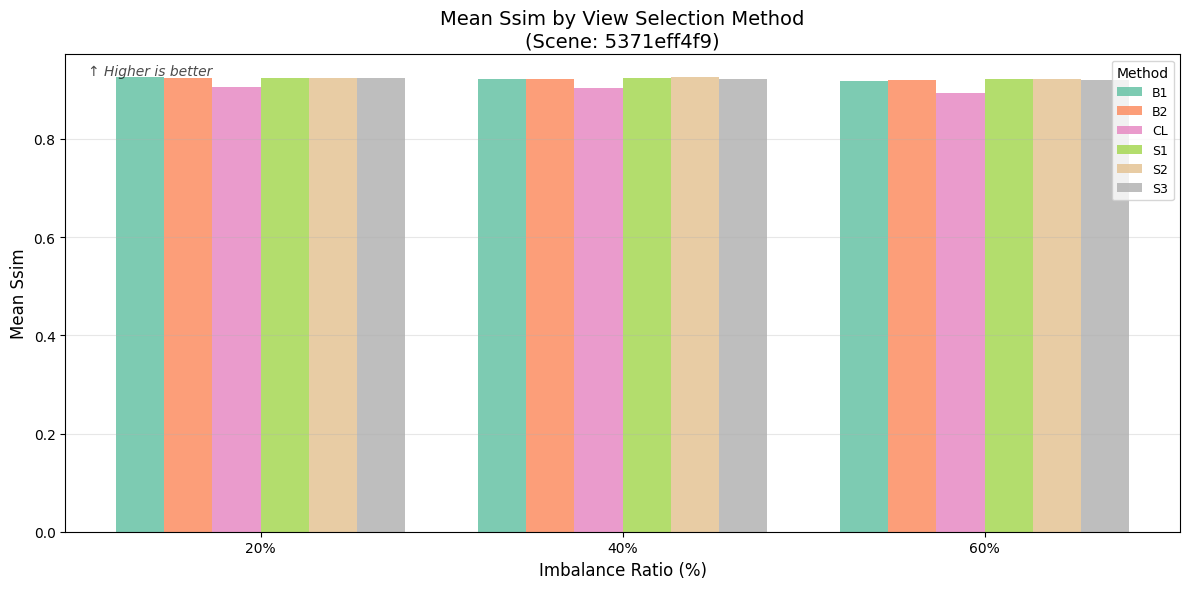

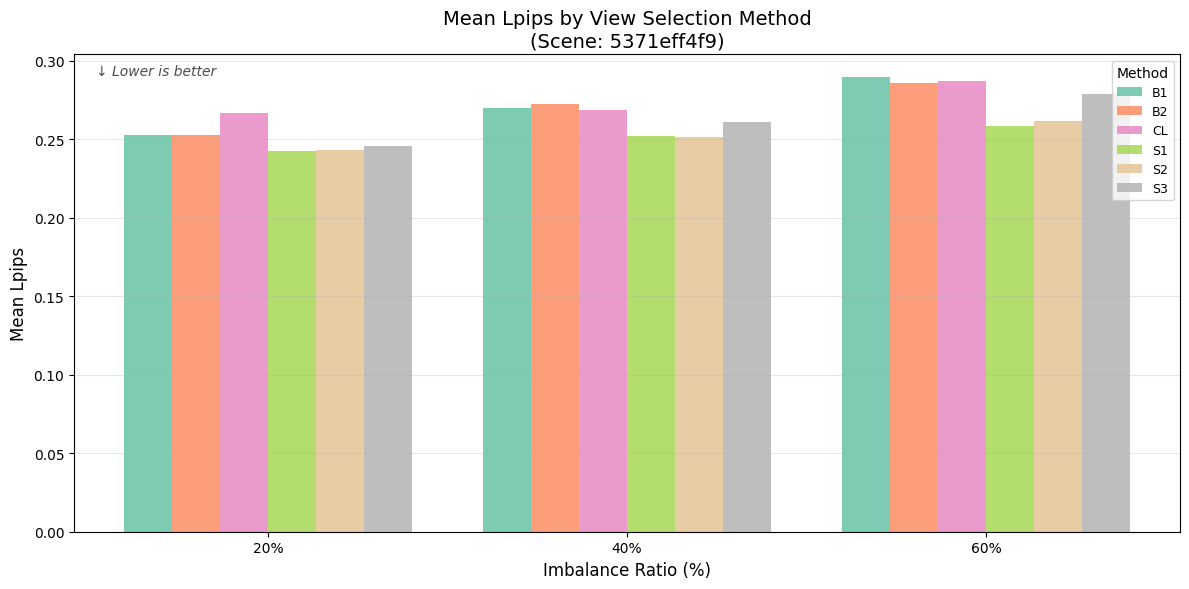

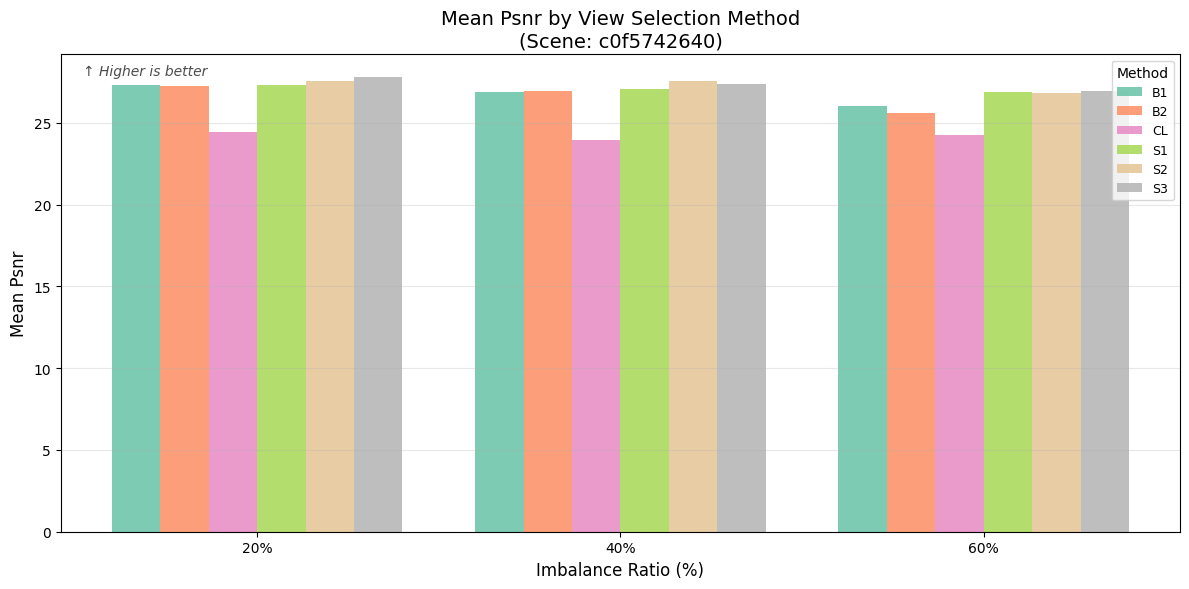

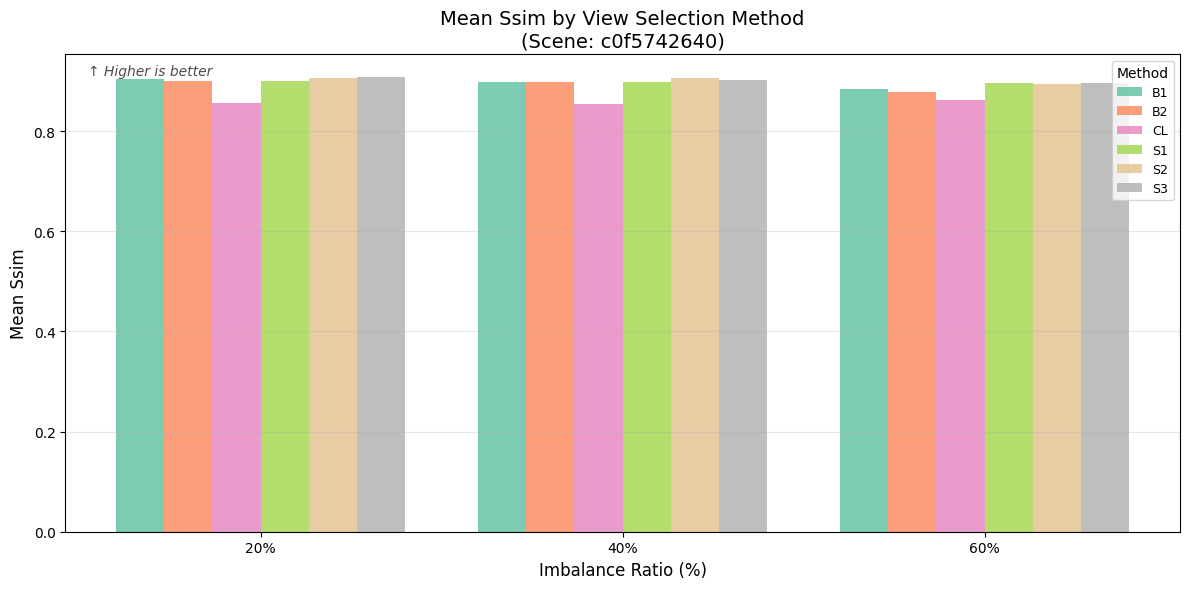

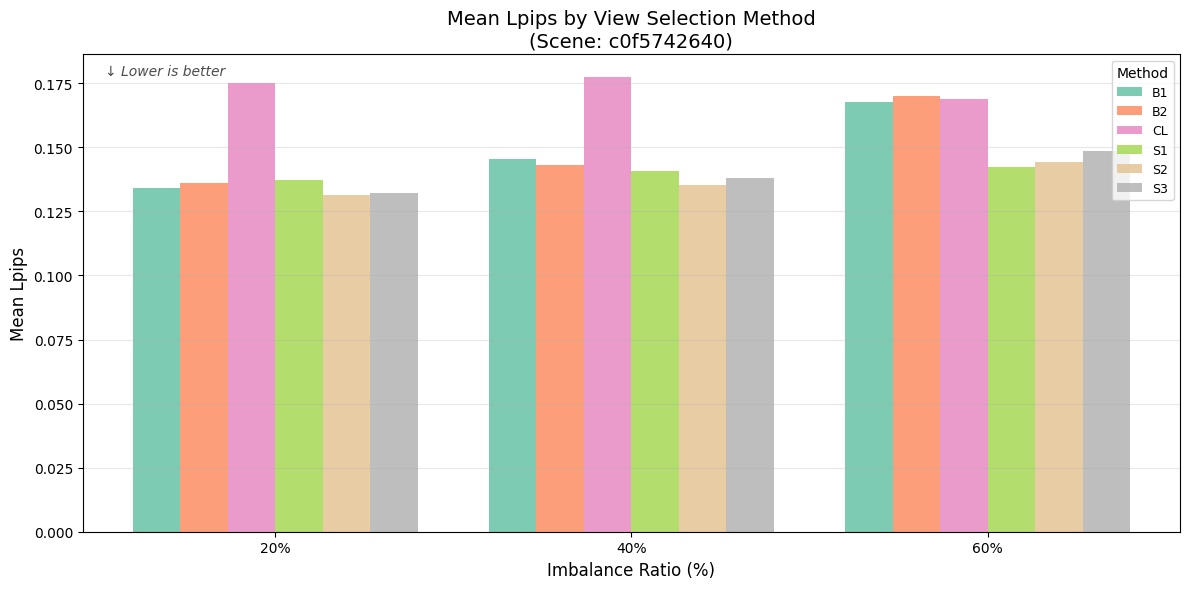


--- Combined Multi-Scene Bar Charts ---


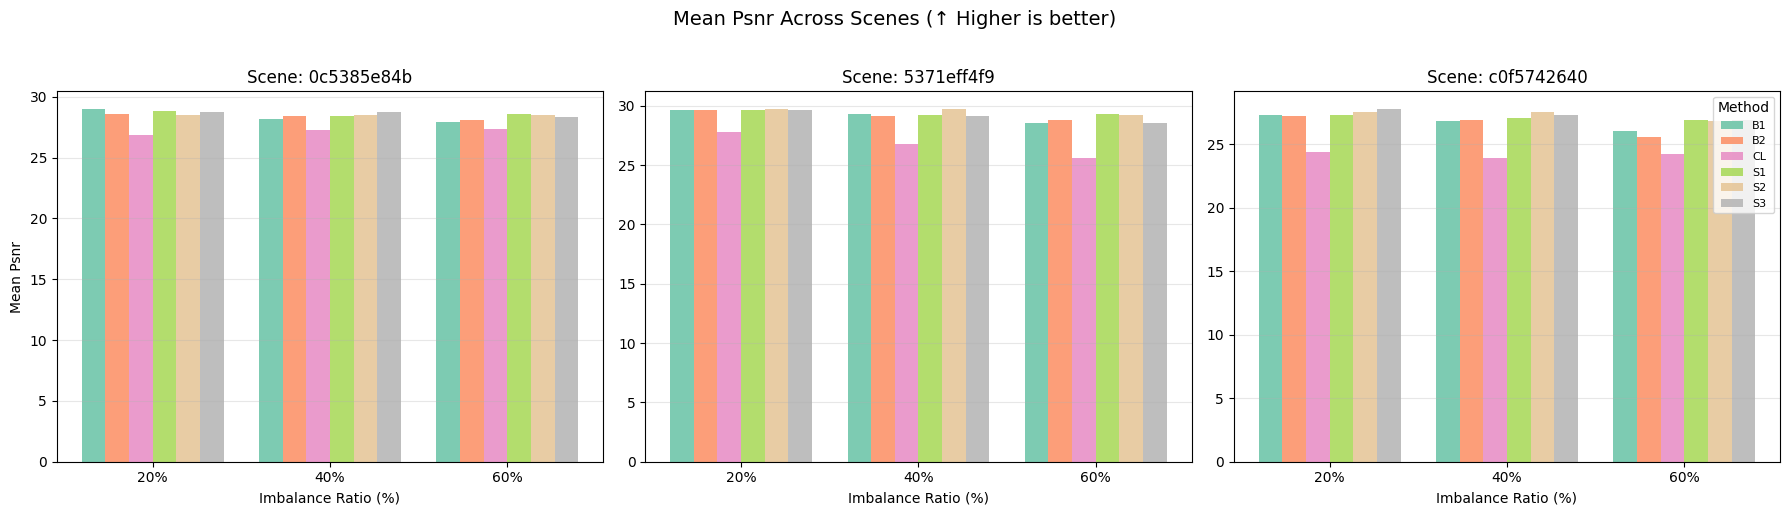

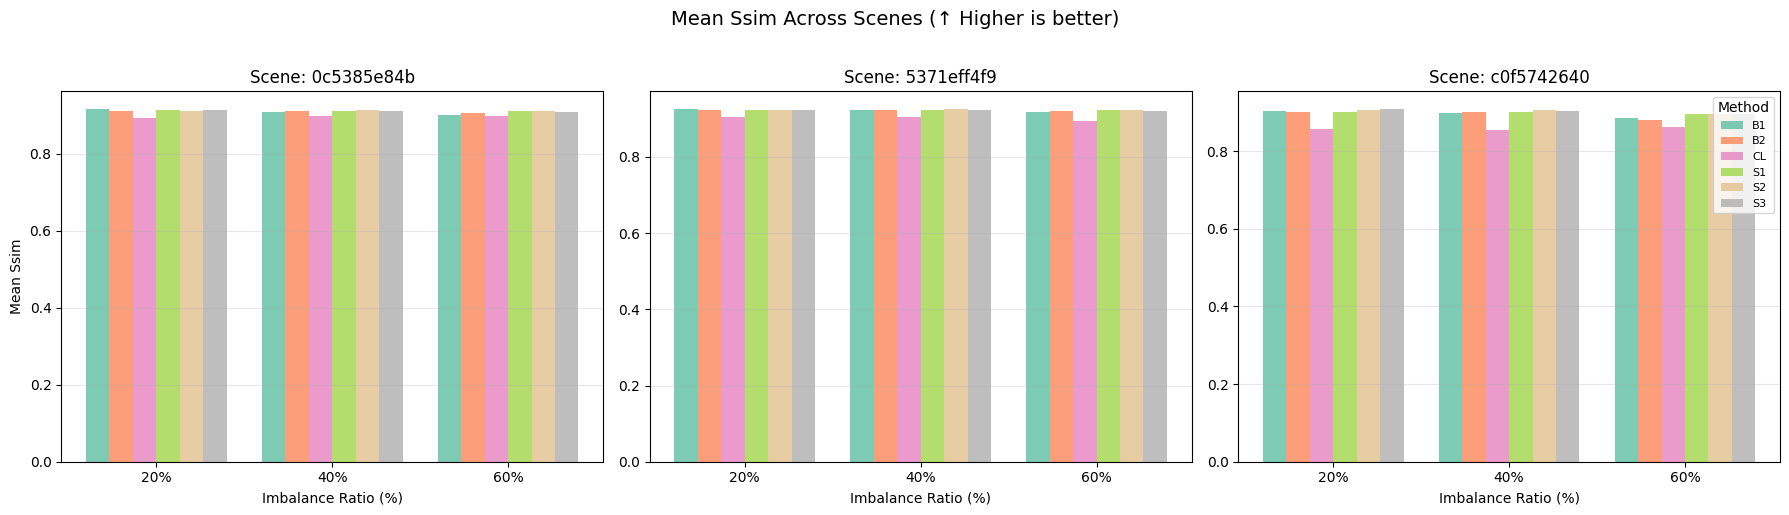

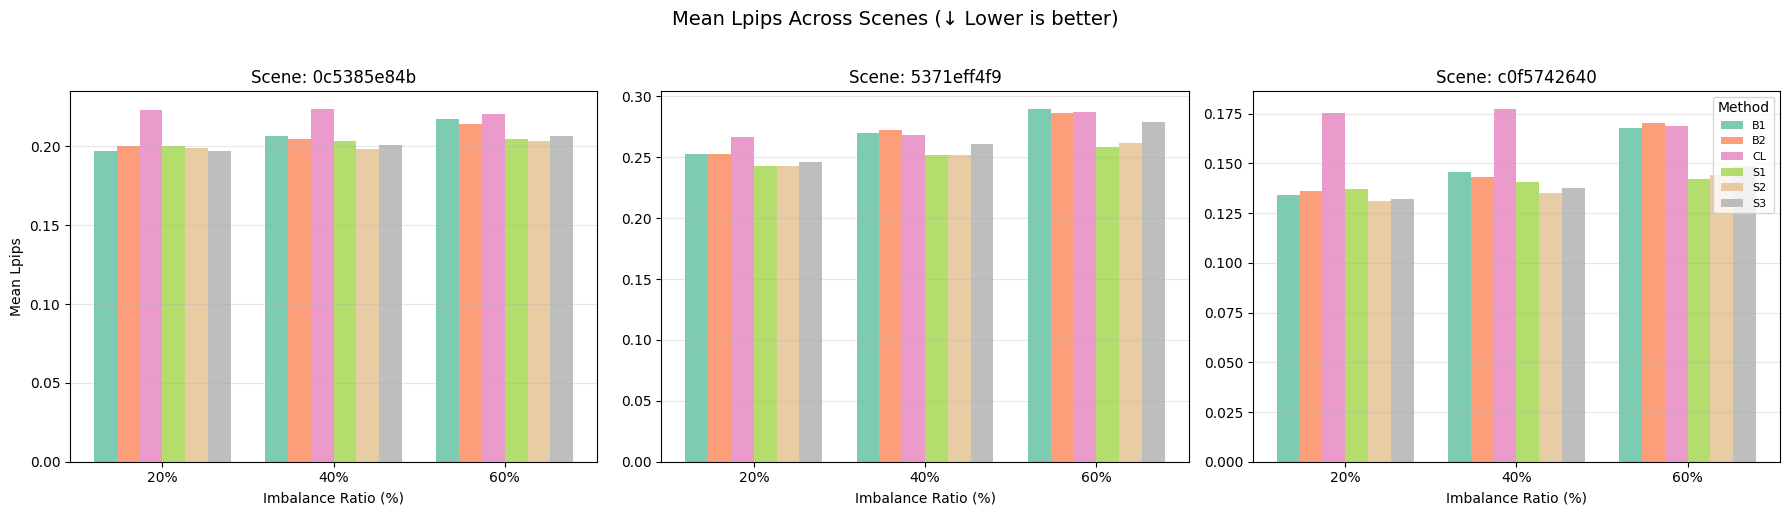

In [7]:
# Save per-run metrics
metrics_per_run_path = NOTEBOOK_OUTPUTS_DIR / "metrics_per_run.csv"
metrics_per_run.to_csv(metrics_per_run_path, index=False)
print("Wrote:", metrics_per_run_path.resolve())

# =========================================================================
# GROUPED BAR CHARTS: Compare methods across imbalance ratios
# These are more informative than scatter plots for categorical comparisons
# =========================================================================

def plot_grouped_bar_chart(df: pd.DataFrame, metric: str, scene: str, higher_is_better: bool = True):
    """
    Create a grouped bar chart with ratio clusters and method bars.
    
    Args:
        df: DataFrame with columns [method, ratio, metric]
        metric: Name of the metric column to plot
        scene: Scene ID for the title
        higher_is_better: If True, higher values are better (PSNR, SSIM). If False, lower is better (LPIPS).
    """
    # Aggregate by method and ratio (mean across seeds)
    agg = df.groupby(["method", "ratio"])[metric].agg(["mean", "std"]).reset_index()
    agg.columns = ["method", "ratio", "mean", "std"]
    agg["ratio"] = pd.to_numeric(agg["ratio"], errors="coerce").astype(int)
    
    methods = sorted(agg["method"].unique())
    ratios = sorted(agg["ratio"].unique())
    
    n_methods = len(methods)
    n_ratios = len(ratios)
    
    # Set up bar positions
    x = np.arange(n_ratios)  # ratio positions
    bar_width = 0.8 / n_methods
    
    # Color palette
    colors = plt.cm.Set2(np.linspace(0, 1, n_methods))
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for i, method in enumerate(methods):
        method_data = agg[agg["method"] == method].set_index("ratio")
        means = [method_data.loc[r, "mean"] if r in method_data.index else np.nan for r in ratios]
        stds = [method_data.loc[r, "std"] if r in method_data.index else 0 for r in ratios]
        
        offset = (i - n_methods / 2 + 0.5) * bar_width
        bars = ax.bar(x + offset, means, bar_width, label=method, color=colors[i],
                      yerr=stds, capsize=3, alpha=0.85)
    
    ax.set_xlabel("Imbalance Ratio (%)", fontsize=12)
    ax.set_ylabel(metric.replace("_", " ").title(), fontsize=12)
    ax.set_title(f"{metric.replace('_', ' ').title()} by View Selection Method\n(Scene: {scene})", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r}%" for r in ratios])
    ax.legend(title="Method", loc="best", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    
    # Add annotation about what's better
    direction = "↑ Higher is better" if higher_is_better else "↓ Lower is better"
    ax.annotate(direction, xy=(0.02, 0.98), xycoords="axes fraction", 
                fontsize=10, ha="left", va="top", style="italic", alpha=0.7)
    
    plt.tight_layout()
    return fig


# Create grouped bar charts for each scene
for base_scene_id in sorted(metrics_per_run["base_scene_id"].unique()):
    sdf = metrics_per_run[metrics_per_run["base_scene_id"] == base_scene_id].copy()
    sdf = sdf.dropna(subset=["ratio", "mean_psnr", "mean_lpips", "mean_ssim"], how="any")
    if len(sdf) == 0:
        continue
    
    # PSNR (higher is better)
    fig = plot_grouped_bar_chart(sdf, "mean_psnr", base_scene_id, higher_is_better=True)
    savefig(f"bar_psnr_{base_scene_id}.png")
    plt.show()
    
    # SSIM (higher is better)  
    fig = plot_grouped_bar_chart(sdf, "mean_ssim", base_scene_id, higher_is_better=True)
    savefig(f"bar_ssim_{base_scene_id}.png")
    plt.show()
    
    # LPIPS (lower is better)
    fig = plot_grouped_bar_chart(sdf, "mean_lpips", base_scene_id, higher_is_better=False)
    savefig(f"bar_lpips_{base_scene_id}.png")
    plt.show()

# =========================================================================
# COMBINED VIEW: All scenes in one plot (faceted by scene)
# =========================================================================
print("\n--- Combined Multi-Scene Bar Charts ---")

all_scenes = sorted(metrics_per_run["base_scene_id"].unique())
n_scenes = len(all_scenes)

if n_scenes > 0:
    for metric, higher_better in [("mean_psnr", True), ("mean_ssim", True), ("mean_lpips", False)]:
        fig, axes = plt.subplots(1, n_scenes, figsize=(6 * n_scenes, 5), sharey=False)
        if n_scenes == 1:
            axes = [axes]
        
        for ax, scene in zip(axes, all_scenes):
            sdf = metrics_per_run[metrics_per_run["base_scene_id"] == scene].copy()
            sdf = sdf.dropna(subset=["ratio", metric])
            if len(sdf) == 0:
                ax.set_title(f"Scene: {scene}\n(no data)")
                continue
            
            agg = sdf.groupby(["method", "ratio"])[metric].mean().reset_index()
            agg["ratio"] = pd.to_numeric(agg["ratio"], errors="coerce").astype(int)
            
            methods = sorted(agg["method"].unique())
            ratios = sorted(agg["ratio"].unique())
            n_methods = len(methods)
            
            x = np.arange(len(ratios))
            bar_width = 0.8 / n_methods
            colors = plt.cm.Set2(np.linspace(0, 1, n_methods))
            
            for i, method in enumerate(methods):
                method_data = agg[agg["method"] == method].set_index("ratio")
                means = [method_data.loc[r, metric] if r in method_data.index else np.nan for r in ratios]
                offset = (i - n_methods / 2 + 0.5) * bar_width
                ax.bar(x + offset, means, bar_width, label=method, color=colors[i], alpha=0.85)
            
            ax.set_xlabel("Imbalance Ratio (%)")
            ax.set_title(f"Scene: {scene}")
            ax.set_xticks(x)
            ax.set_xticklabels([f"{r}%" for r in ratios])
            ax.grid(axis="y", alpha=0.3)
        
        axes[0].set_ylabel(metric.replace("_", " ").title())
        axes[-1].legend(title="Method", loc="best", fontsize=8)
        
        direction = "↑ Higher is better" if higher_better else "↓ Lower is better"
        fig.suptitle(f"{metric.replace('_', ' ').title()} Across Scenes ({direction})", fontsize=14, y=1.02)
        plt.tight_layout()
        savefig(f"bar_combined_{metric.split('_')[1]}.png")
        plt.show()

Wrote: /home/fgrob/gaussian-splatting/notebook_outputs/ablation_imbalanced_sanity_v1_analysis/test_curves_timeseries.csv


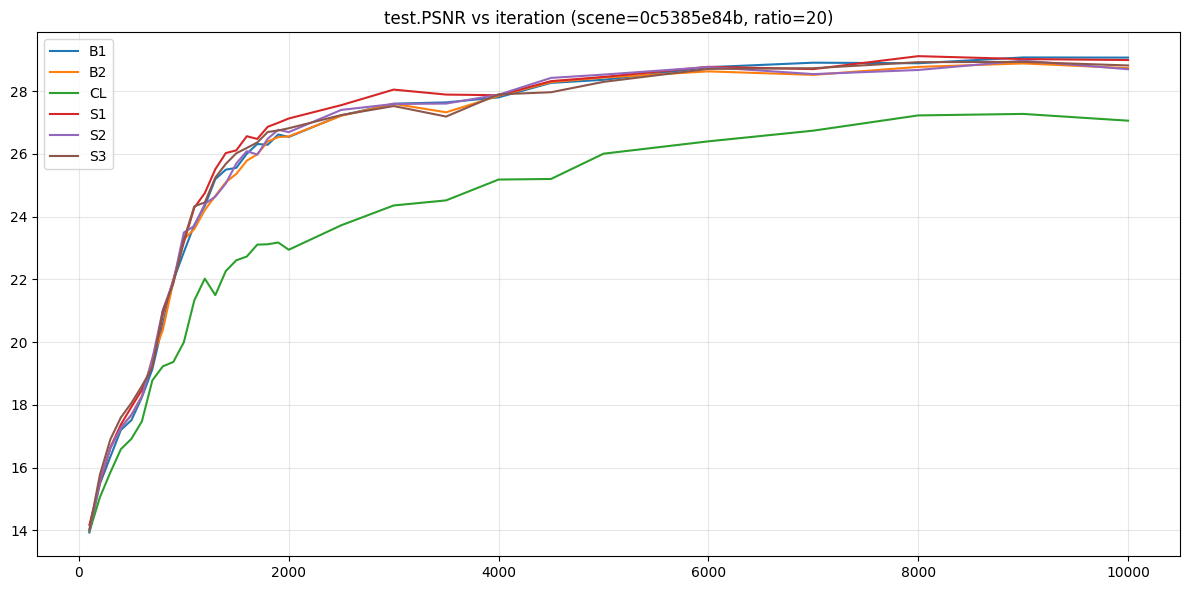

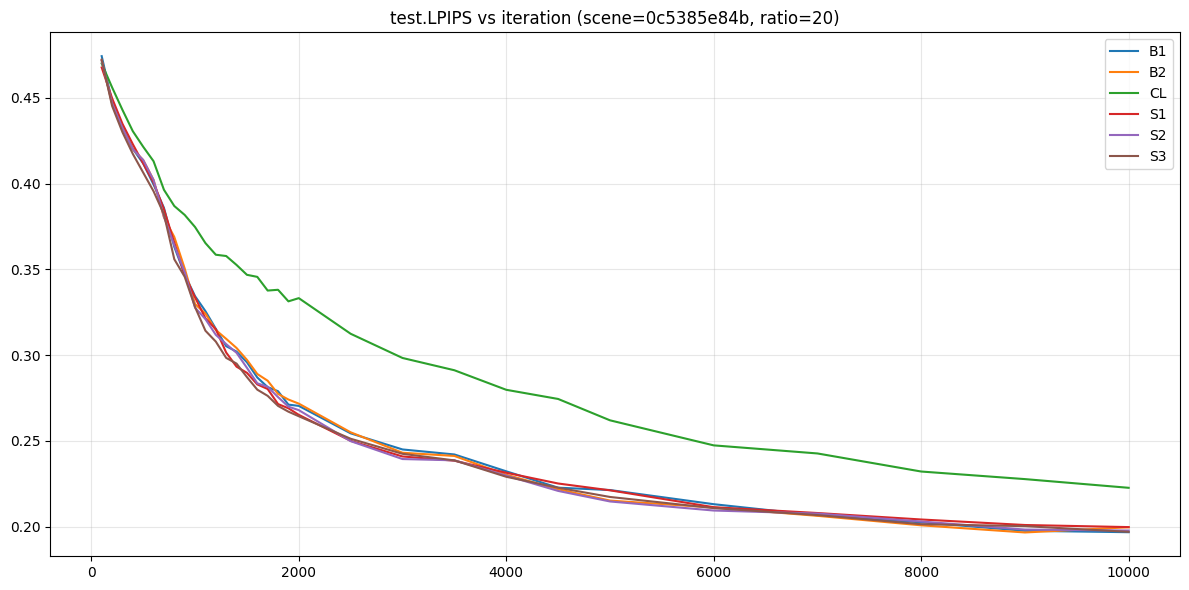

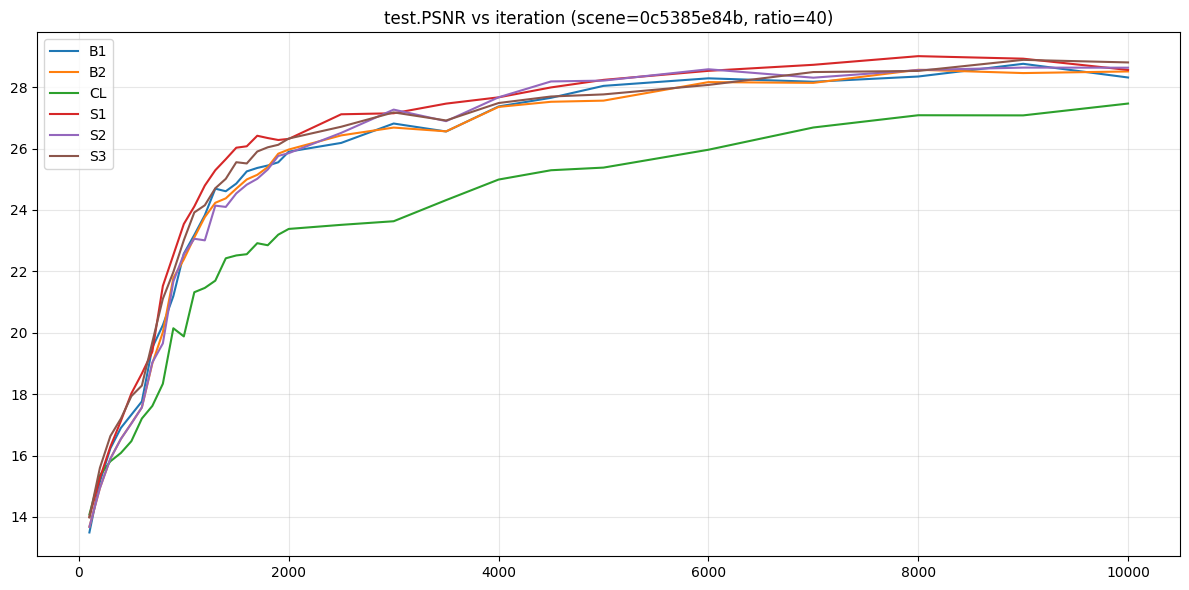

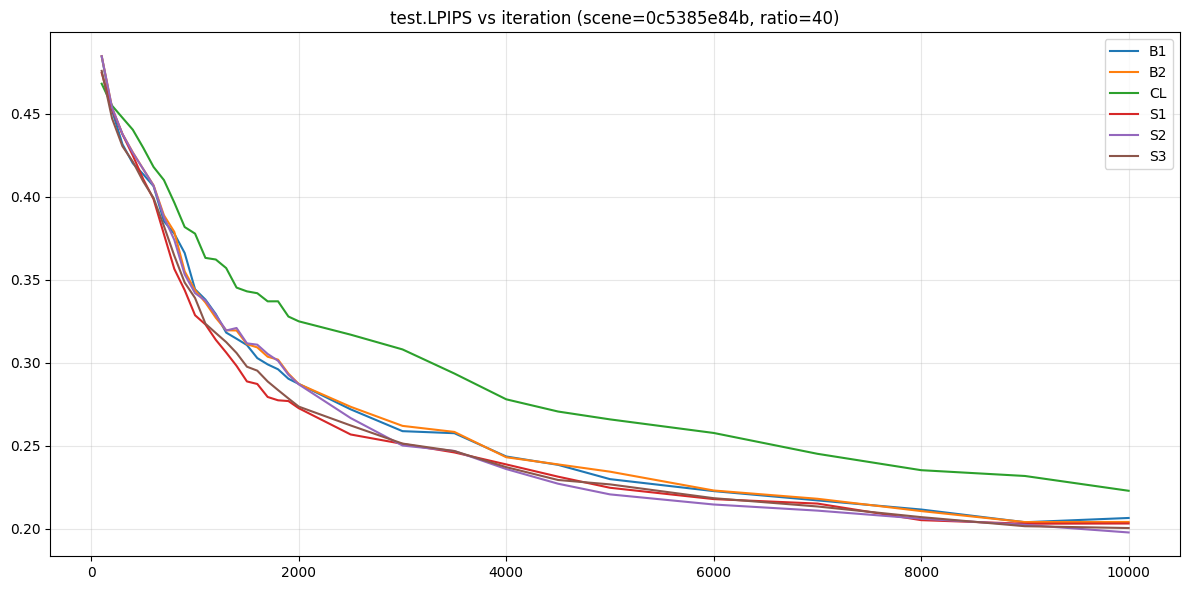

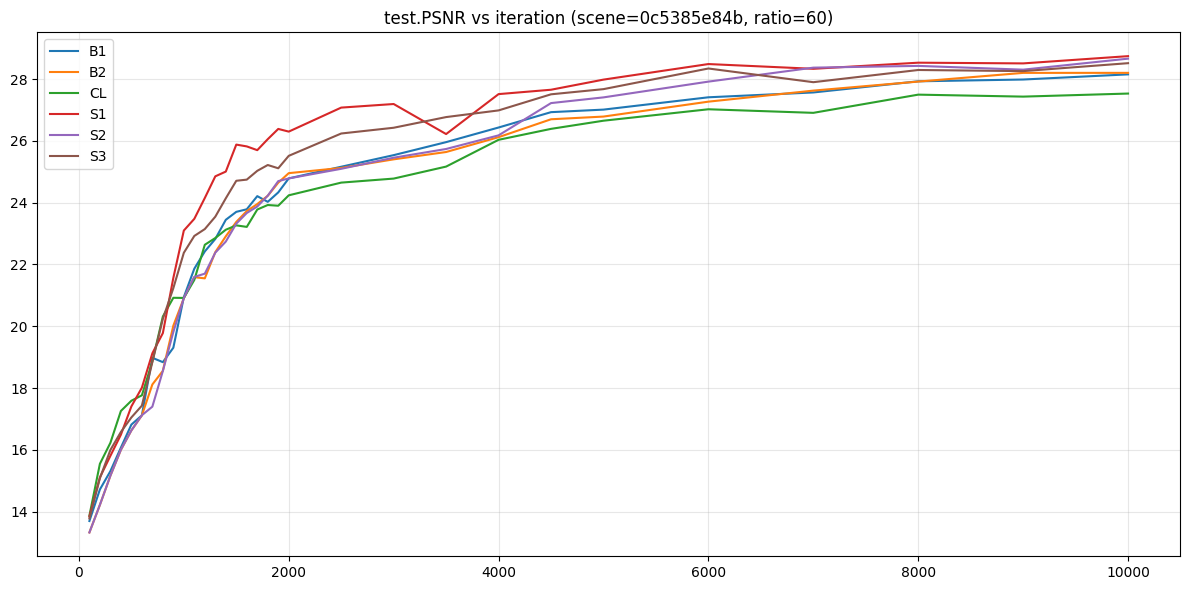

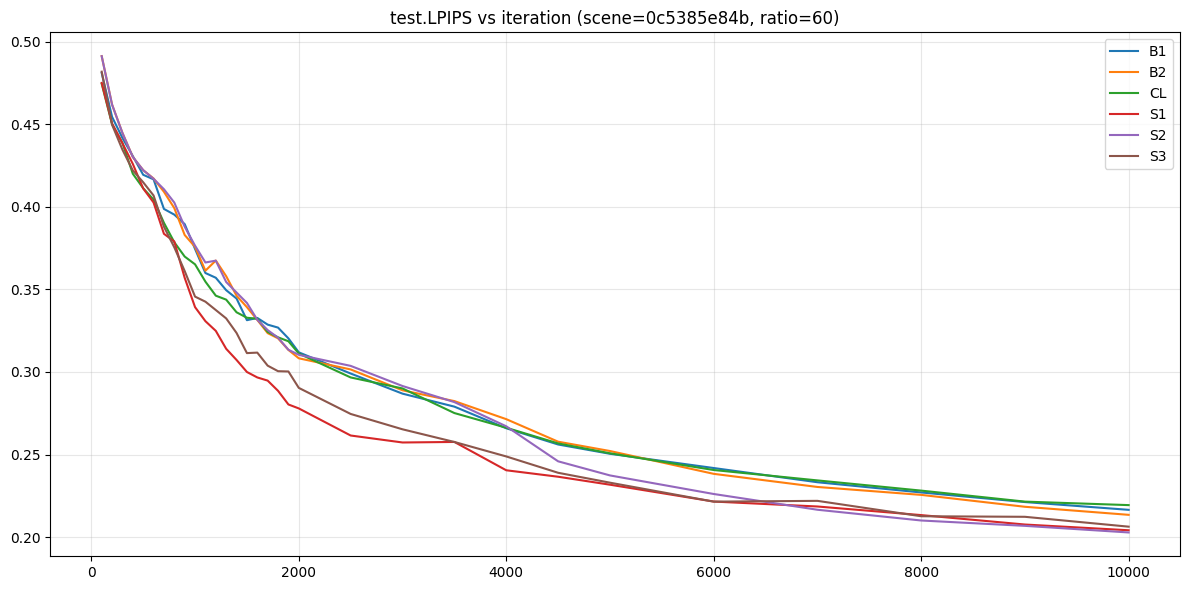

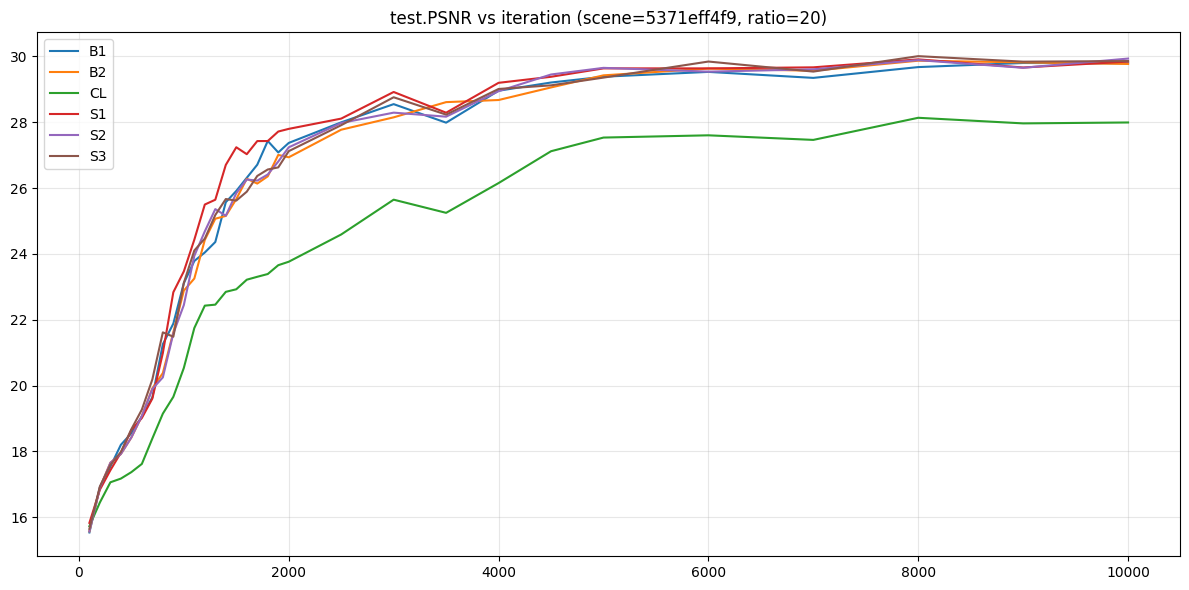

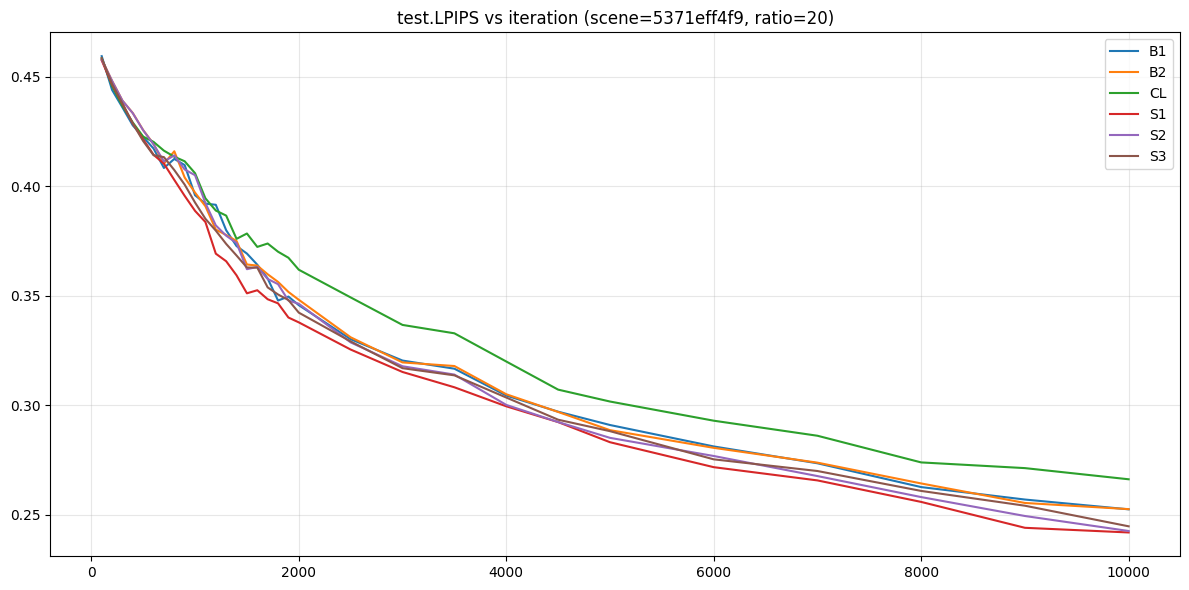

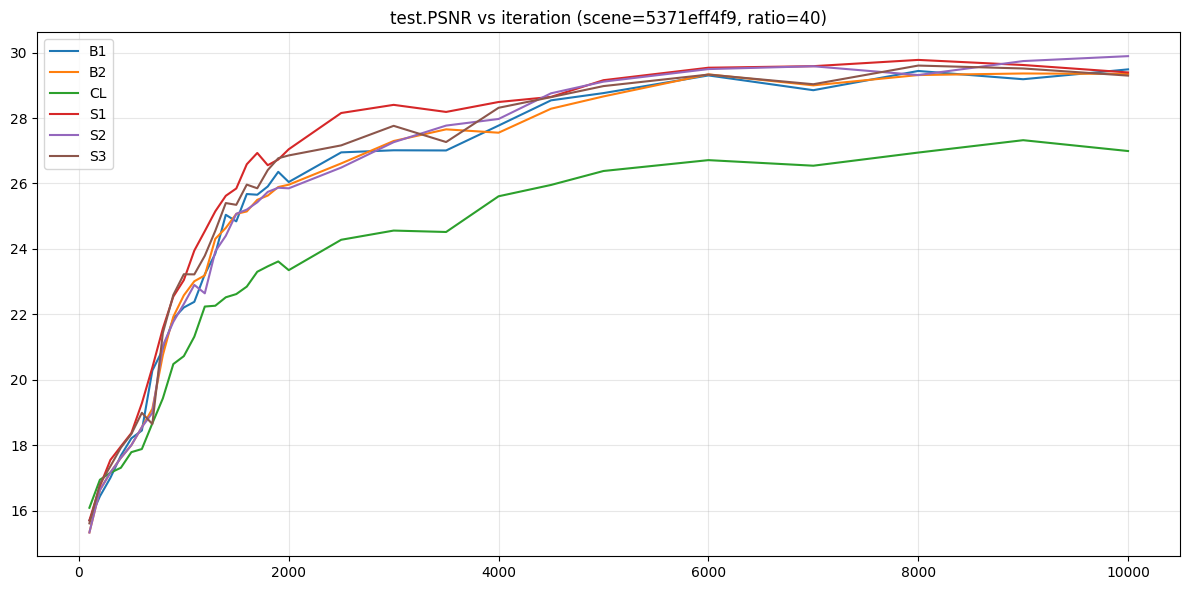

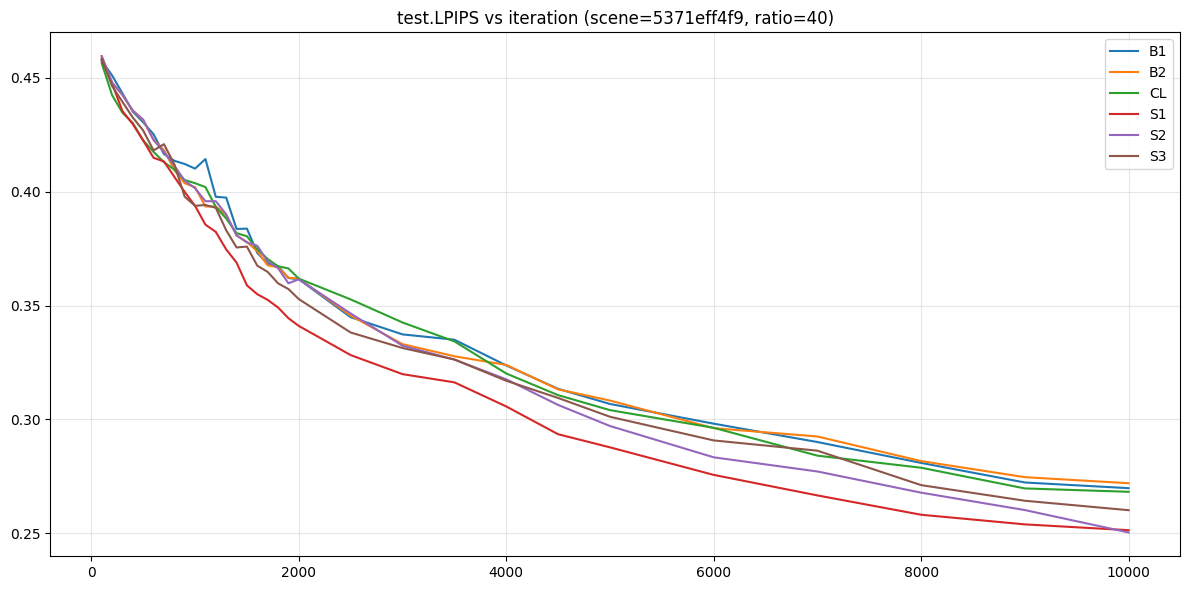

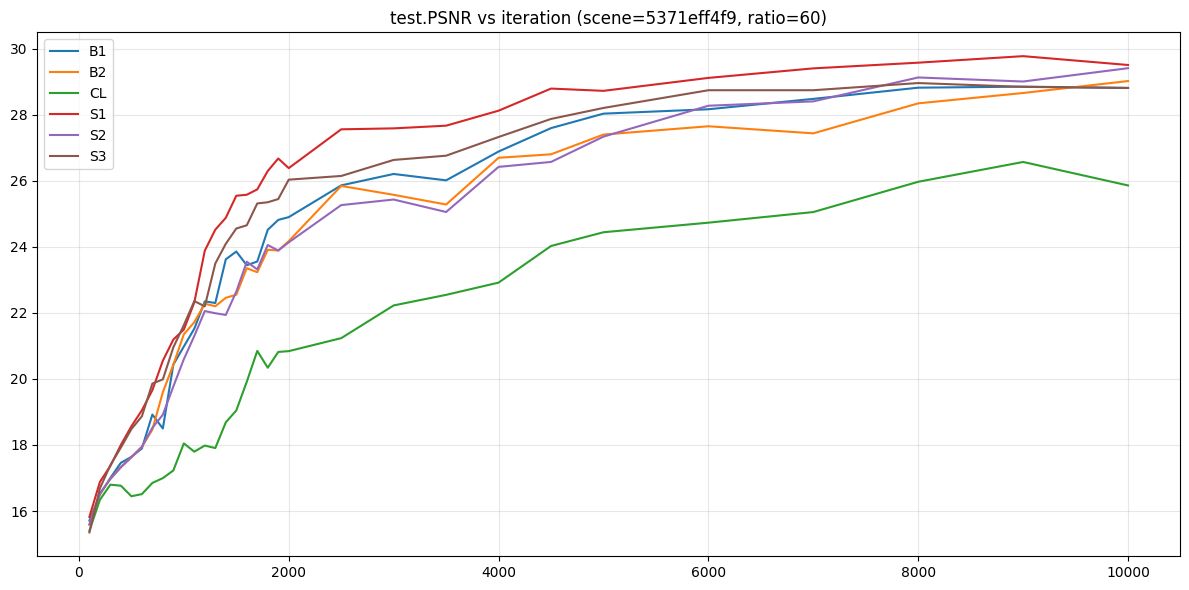

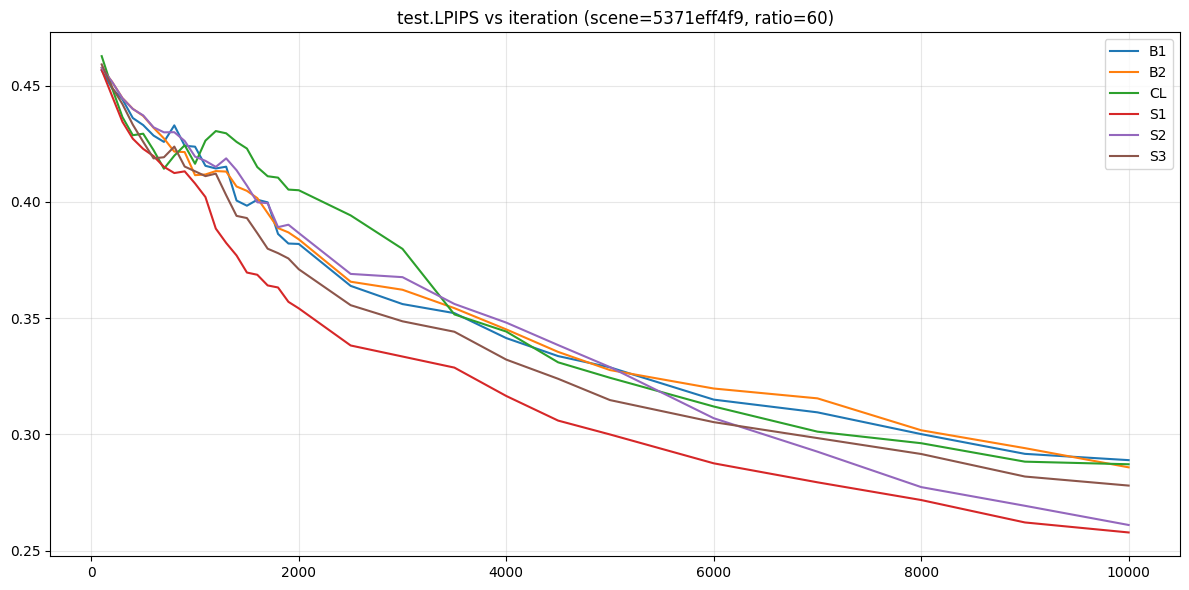

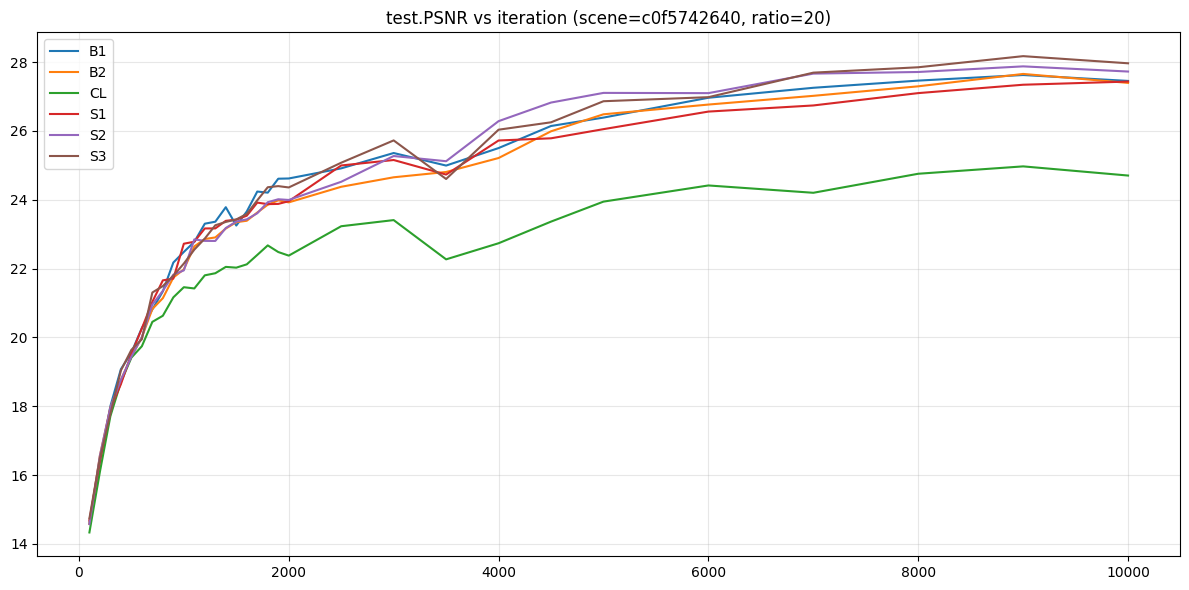

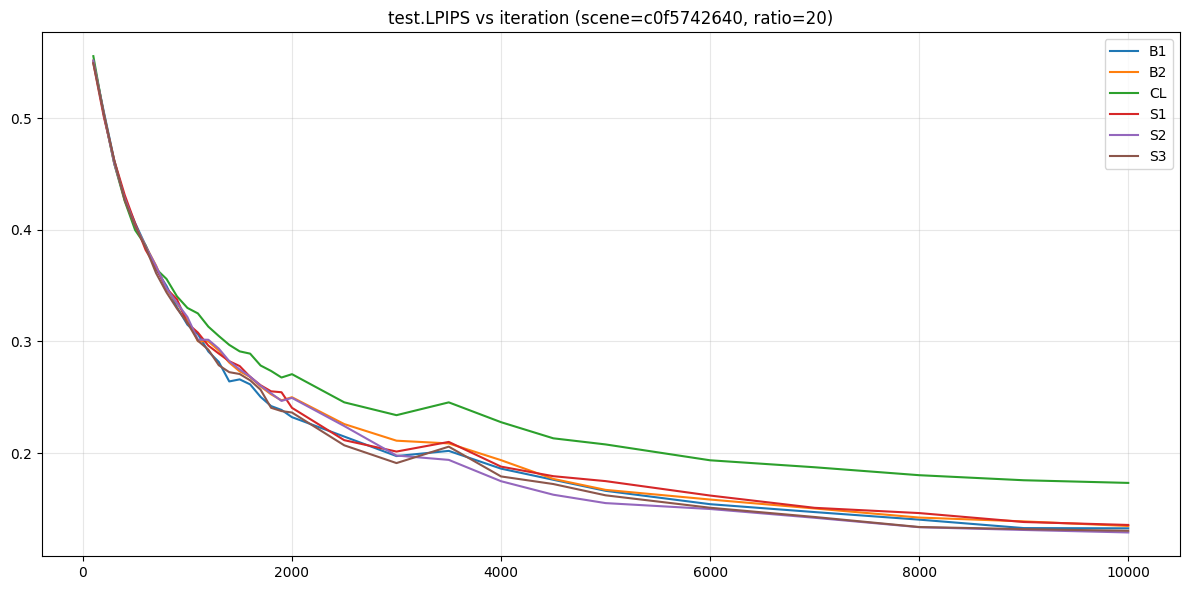

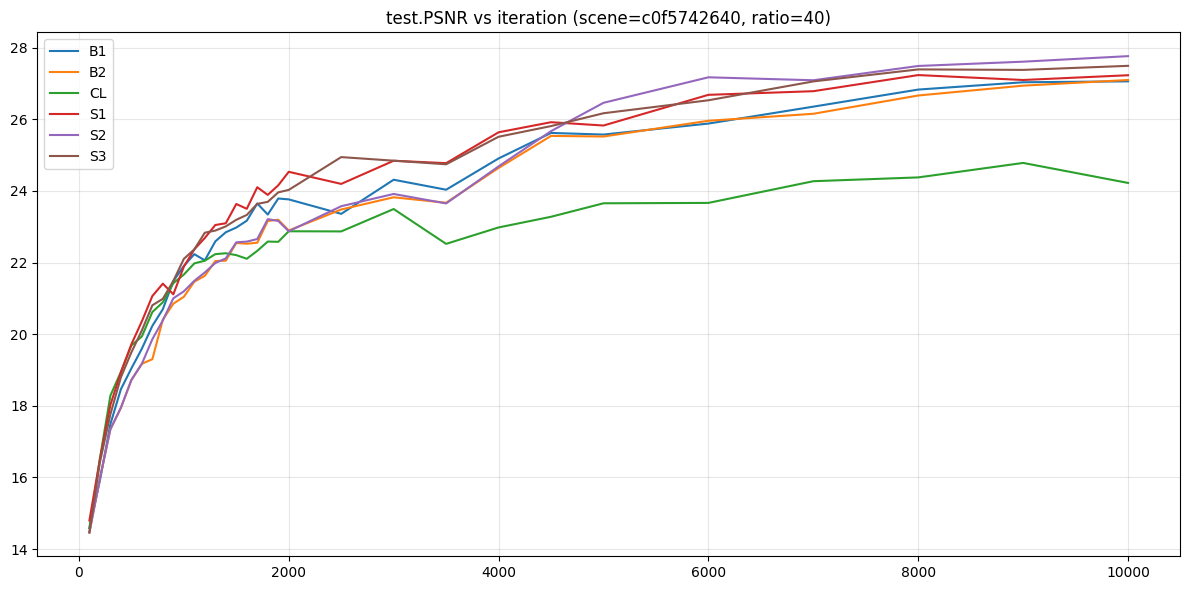

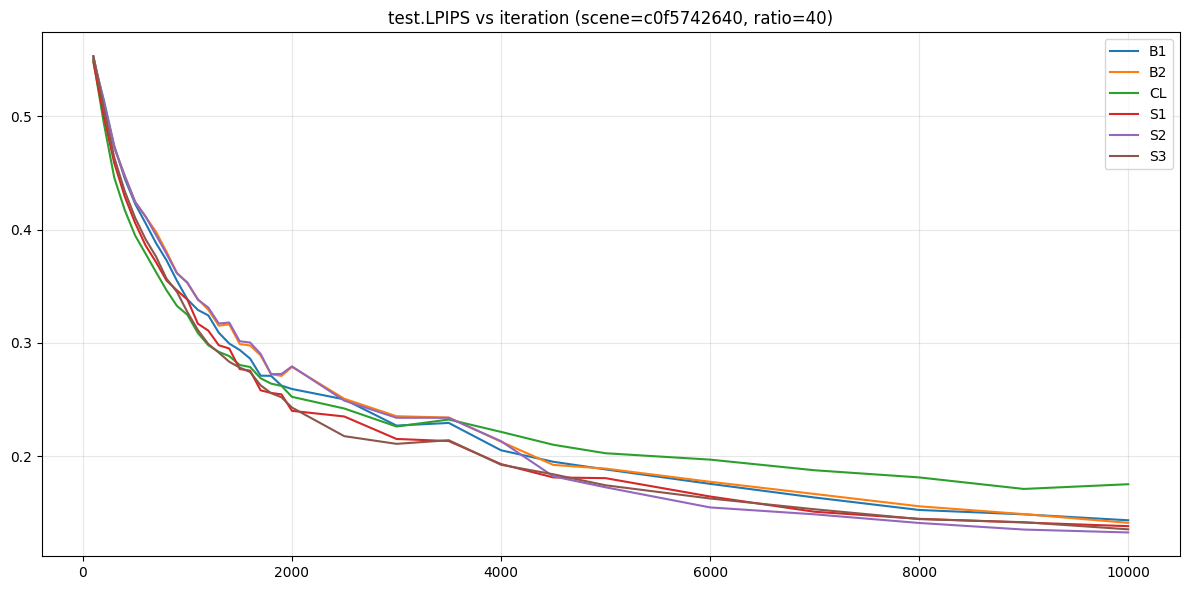

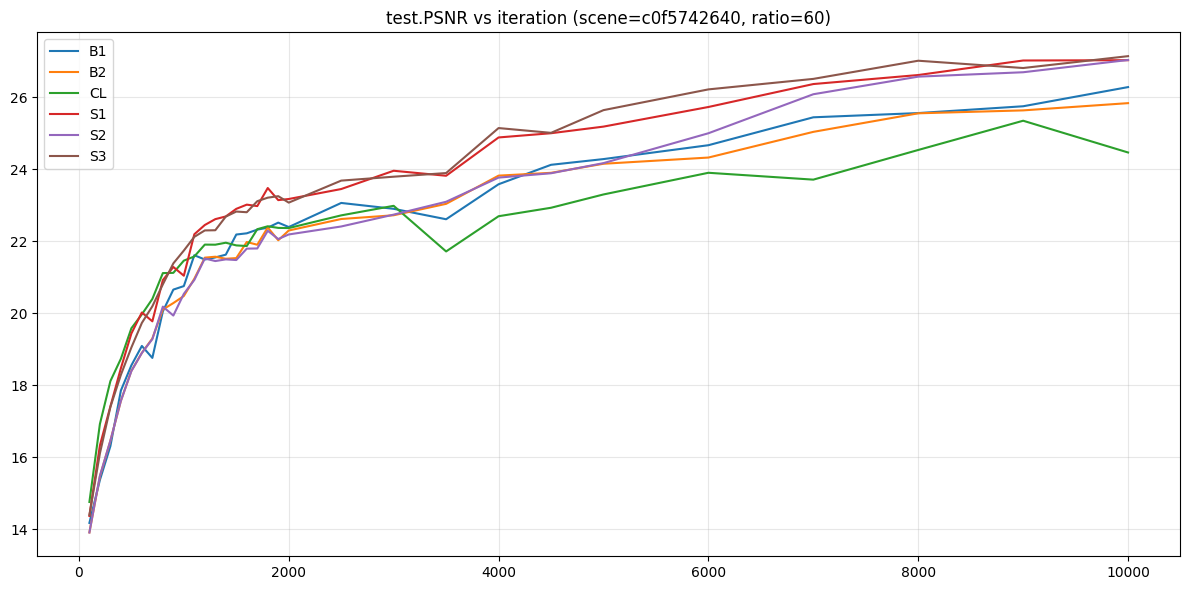

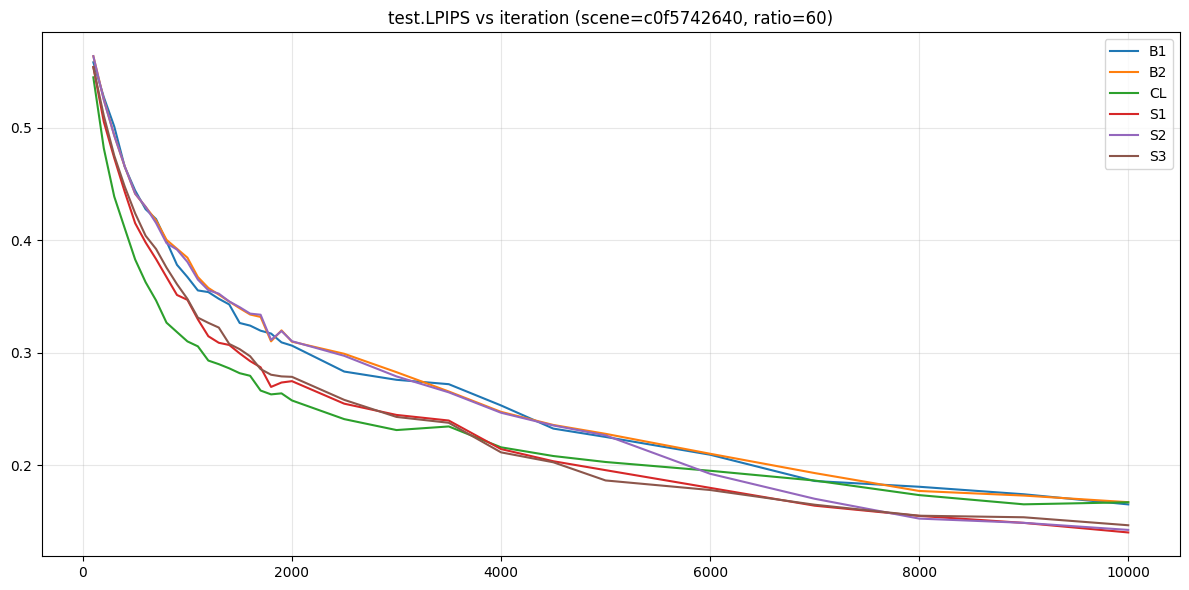

In [8]:
# -----------------------------
# 4b. Test PSNR/LPIPS over time
# -----------------------------
# Per your request: per scene AND per imbalance ratio, show test metric vs iteration.

def metrics_history_to_test_curve_df(history: List[dict]) -> pd.DataFrame:
    rows = []
    for rec in history:
        it = rec.get("iteration")
        if it is None:
            continue
        t = rec.get("test")
        if not isinstance(t, dict):
            continue
        for k in ("PSNR", "LPIPS"):
            if k in t:
                rows.append({"iteration": int(it), "metric": f"test.{k}", "value": float(t[k])})
    return pd.DataFrame(rows)


curve_rows = []
for r in runs:
    hist = load_metrics_history(r.run_dir)
    if not hist:
        continue
    dfc = metrics_history_to_test_curve_df(hist)
    if dfc.empty:
        continue
    dfc = dfc.copy()
    dfc["method"] = r.method
    dfc["scene"] = r.scene
    dfc["base_scene_id"] = r.base_scene_id
    dfc["ratio"] = r.ratio
    dfc["seed"] = r.seed
    curve_rows.append(dfc)

test_curves = pd.concat(curve_rows, ignore_index=True) if curve_rows else pd.DataFrame()
test_curves_path = NOTEBOOK_OUTPUTS_DIR / "test_curves_timeseries.csv"
if len(test_curves) > 0:
    test_curves.to_csv(test_curves_path, index=False)
    print("Wrote:", test_curves_path.resolve())
else:
    print("No test_curves found (missing metrics_history.json?)")

if len(test_curves) > 0:
    for base_scene_id in sorted(test_curves["base_scene_id"].dropna().unique()):
        sdf_scene = test_curves[test_curves["base_scene_id"] == base_scene_id].copy()
        for ratio in sorted(pd.to_numeric(sdf_scene["ratio"], errors="coerce").dropna().unique()):
            sdf = sdf_scene[pd.to_numeric(sdf_scene["ratio"], errors="coerce") == ratio]
            if len(sdf) == 0:
                continue
            for metric in ("test.PSNR", "test.LPIPS"):
                dfm = sdf[sdf["metric"] == metric].copy()
                if len(dfm) == 0:
                    continue
                plt.figure(figsize=(12, 6))
                if sns is not None:
                    sns.lineplot(data=dfm, x="iteration", y="value", hue="method")
                else:
                    for method, g in dfm.groupby("method"):
                        plt.plot(g["iteration"], g["value"], label=str(method))
                    plt.legend()
                plt.title(f"{metric} vs iteration (scene={base_scene_id}, ratio={int(ratio)})") 
                plt.grid(True, alpha=0.3)
                fname = f"{metric.replace('.', '_').lower()}_curve_{base_scene_id}_r{int(ratio)}.png"
                savefig(fname)
                plt.show()

## 5. Normalize into a tidy DataFrame (run_id, method, scene, ratio, seed, step)

We create canonical IDs and a tidy form that’s easy to join across metrics and selection stats.

In [9]:
metrics_per_run = metrics_per_run.copy()
metrics_per_run["run_id"] = metrics_per_run.apply(
    lambda r: f"{r['method']}/{r['scene']}/seed{int(r['seed'])}", axis=1
)

# Ensure numeric dtypes (keep NaNs)
for col in [
    "ratio",
    "mean_psnr",
    "mean_ssim",
    "mean_lpips",
    "best_test_psnr",
    "final_test_psnr",
    "best_test_lpips",
    "final_test_lpips",
    "best_test_ssim",
    "final_test_ssim",
    "best_test_l1",
    "final_test_l1",
    "num_total",
    "num_train",
    "num_test",
]:
    if col in metrics_per_run.columns:
        metrics_per_run[col] = pd.to_numeric(metrics_per_run[col], errors="coerce")

metrics_per_run[["run_id", "method", "base_scene_id", "ratio", "seed", "mean_psnr", "mean_lpips"]].head()

,run_id,method,base_scene_id,ratio,seed,mean_psnr,mean_lpips
0,B1/0c5385e84b_imb20_rand1/seed0,B1,0c5385e84b,20,0,28.991044,0.196999
1,B1/0c5385e84b_imb40_rand1/seed0,B1,0c5385e84b,40,0,28.175883,0.206878
2,B1/0c5385e84b_imb60_rand1/seed0,B1,0c5385e84b,60,0,27.924447,0.217512
3,B1/5371eff4f9_imb20_rand1/seed0,B1,5371eff4f9,20,0,29.651240,0.252765
4,B1/5371eff4f9_imb40_rand1/seed0,B1,5371eff4f9,40,0,29.326021,0.269953


## 6. Aggregate metrics per run (best/last) + confidence intervals across seeds

We compute mean/std and a 95% CI as:

$$\text{CI} = \bar{x} \pm 1.96\,\sigma/\sqrt{n}$$

(when $n>1$).

In [10]:
def mean_std_ci(x: pd.Series) -> Tuple[float, float, float]:
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0:
        return float("nan"), float("nan"), float("nan")
    mu = float(x.mean())
    sd = float(x.std(ddof=1)) if len(x) > 1 else 0.0
    ci = 1.96 * sd / math.sqrt(len(x)) if len(x) > 1 else 0.0
    return mu, sd, ci


GROUP_KEYS = ["method", "base_scene_id", "ratio"]
METRIC_COLS = [
    "mean_psnr",
    "mean_ssim",
    "mean_lpips",
    "best_test_psnr",
    "best_test_ssim",
    "best_test_lpips",
    "final_test_psnr",
    "final_test_ssim",
    "final_test_lpips",
]

agg_rows = []
for keys, g in metrics_per_run.groupby(GROUP_KEYS, dropna=False):
    row = {k: v for k, v in zip(GROUP_KEYS, keys)}
    row["n"] = int(g["seed"].nunique())
    for col in METRIC_COLS:
        if col not in g.columns:
            continue
        mu, sd, ci = mean_std_ci(g[col])
        row[f"{col}_mean"] = mu
        row[f"{col}_std"] = sd
        row[f"{col}_ci95"] = ci
    agg_rows.append(row)

aggregated_metrics = pd.DataFrame(agg_rows).sort_values(GROUP_KEYS).reset_index(drop=True)

aggregated_metrics_path = NOTEBOOK_OUTPUTS_DIR / "aggregated_metrics.csv"
aggregated_metrics.to_csv(aggregated_metrics_path, index=False)
print("Wrote:", aggregated_metrics_path.resolve())

aggregated_metrics.head()

Wrote: /home/fgrob/gaussian-splatting/notebook_outputs/ablation_imbalanced_sanity_v1_analysis/aggregated_metrics.csv


,method,base_scene_id,ratio,n,mean_psnr_mean,mean_psnr_std,mean_psnr_ci95,mean_ssim_mean,mean_ssim_std,mean_ssim_ci95,...,best_test_lpips_ci95,final_test_psnr_mean,final_test_psnr_std,final_test_psnr_ci95,final_test_ssim_mean,final_test_ssim_std,final_test_ssim_ci95,final_test_lpips_mean,final_test_lpips_std,final_test_lpips_ci95
0,B1,0c5385e84b,20,1,28.991044,0.0,0.0,0.916927,0.0,0.0,...,0.0,29.067136,0.0,0.0,0.917310,0.0,0.0,0.196702,0.0,0.0
1,B1,0c5385e84b,40,1,28.175883,0.0,0.0,0.909106,0.0,0.0,...,0.0,28.315573,0.0,0.0,0.909859,0.0,0.0,0.206441,0.0,0.0
2,B1,0c5385e84b,60,1,27.924447,0.0,0.0,0.902470,0.0,0.0,...,0.0,28.152283,0.0,0.0,0.904126,0.0,0.0,0.216484,0.0,0.0
3,B1,5371eff4f9,20,1,29.651240,0.0,0.0,0.925555,0.0,0.0,...,0.0,29.787829,0.0,0.0,0.925894,0.0,0.0,0.252559,0.0,0.0
4,B1,5371eff4f9,40,1,29.326021,0.0,0.0,0.922464,0.0,0.0,...,0.0,29.486177,0.0,0.0,0.922698,0.0,0.0,0.269806,0.0,0.0


## 7. Compare methods per scene across imbalance ratios (tables + plots)

We produce per-scene tables and curves for PSNR/SSIM/LPIPS.

In [11]:
def pivot_metric(metric: str) -> pd.DataFrame:
    return metrics_per_run.pivot_table(
        index=["base_scene_id", "ratio"],
        columns="method",
        values=metric,
        aggfunc="mean",
    )


display(pivot_metric("mean_psnr"))

# Overall macro-average (average over scenes/ratios equally)
macro = (
    metrics_per_run.groupby(["method", "base_scene_id", "ratio"])[["mean_psnr", "mean_ssim", "mean_lpips"]]
    .mean()
    .reset_index()
    .groupby("method")[["mean_psnr", "mean_ssim", "mean_lpips"]]
    .mean()
    .sort_values("mean_psnr", ascending=False)
)
print("Macro-average over (scene,ratio):")
display(macro)

# Leaderboard per scene
for base_scene_id in sorted(metrics_per_run["base_scene_id"].unique()):
    sdf = metrics_per_run[metrics_per_run["base_scene_id"] == base_scene_id]
    lb = sdf.groupby(["method", "ratio"])[["mean_psnr", "mean_ssim", "mean_lpips"]].mean().reset_index()
    print(f"\nScene: {base_scene_id}")
    display(lb.sort_values(["ratio", "mean_psnr"], ascending=[True, False]))

method                      B1         B2         CL         S1         S2  \
base_scene_id ratio                                                          
0c5385e84b    20     28.991044  28.609040  26.865813  28.832604  28.515573   
              40     28.175883  28.389935  27.273868  28.428245  28.490103   
              60     27.924447  28.063193  27.341143  28.614360  28.506137   
5371eff4f9    20     29.651240  29.613212  27.761091  29.654159  29.737551   
              40     29.326021  29.163946  26.782833  29.249098  29.711924   
              60     28.588324  28.796660  25.636710  29.346238  29.205312   
c0f5742640    20     27.296774  27.236351  24.434850  27.286696  27.526797   
              40     26.864902  26.937665  23.963313  27.054015  27.539565   
              60     26.016619  25.611827  24.242955  26.901800  26.831033   

method                      S3  
base_scene_id ratio             
0c5385e84b    20     28.702239  
              40     28.702831  
              60     28.355145  
5371eff4f9    20     29.663865  
              40     29.133237  
              60     28.555174  
c0f5742640    20     27.789632  
              40     27.352317  
              60     26.951913

Macro-average over (scene,ratio):


,mean_psnr,mean_ssim,mean_lpips
method,,,
S2,28.451555,0.913008,0.196452
S1,28.374135,0.911459,0.197994
S3,28.356261,0.912409,0.201045
B1,28.092806,0.909007,0.209027
B2,28.046870,0.908222,0.208880
CL,26.033620,0.885531,0.223610



Scene: 0c5385e84b


,method,ratio,mean_psnr,mean_ssim,mean_lpips
0,B1,20,28.991044,0.916927,0.196999
9,S1,20,28.832604,0.913806,0.200314
15,S3,20,28.702239,0.914771,0.197279
3,B2,20,28.609040,0.912251,0.200102
12,S2,20,28.515573,0.912733,0.198830
6,CL,20,26.865813,0.894684,0.223456
16,S3,40,28.702831,0.912635,0.200730
13,S2,40,28.490103,0.913233,0.198538
10,S1,40,28.428245,0.912052,0.203607
4,B2,40,28.389935,0.911284,0.204746



Scene: 5371eff4f9


,method,ratio,mean_psnr,mean_ssim,mean_lpips
12,S2,20,29.737551,0.924241,0.243265
15,S3,20,29.663865,0.924120,0.245857
9,S1,20,29.654159,0.924536,0.242497
0,B1,20,29.651240,0.925555,0.252765
3,B2,20,29.613212,0.923526,0.252966
6,CL,20,27.761091,0.906106,0.267071
13,S2,40,29.711924,0.926064,0.251557
1,B1,40,29.326021,0.922464,0.269953
10,S1,40,29.249098,0.923342,0.251894
4,B2,40,29.163946,0.922208,0.272352



Scene: c0f5742640


,method,ratio,mean_psnr,mean_ssim,mean_lpips
15,S3,20,27.789632,0.908242,0.132182
12,S2,20,27.526797,0.905457,0.131377
0,B1,20,27.296774,0.904183,0.134232
9,S1,20,27.286696,0.901293,0.137290
3,B2,20,27.236351,0.901162,0.136200
6,CL,20,24.434850,0.856901,0.175259
13,S2,40,27.539565,0.905640,0.135392
16,S3,40,27.352317,0.902818,0.137881
10,S1,40,27.054015,0.899207,0.140914
4,B2,40,26.937665,0.899251,0.142980


## 8. Method Improvement vs Baselines (per ratio)

**Key Question**: How much do our selection methods improve over baselines (`uniform_random`, `stack`) at each imbalance ratio?

For each imbalance ratio, we compute:
- $\Delta\text{PSNR} = \text{PSNR}_{\text{method}} - \text{PSNR}_{\text{baseline}}$
- Similar for SSIM (positive = better) and LPIPS (negative = better)

This directly tests the hypothesis: **As imbalance increases, smart selection methods should show larger improvements over naive baselines.**

In [12]:
# Define which methods are baselines vs our proposed methods
BASELINE_METHODS = ["uniform_random", "stack"]  # Naive methods that don't account for imbalance

# Get all methods and identify proposed ones
all_methods = set(metrics_per_run["method"].unique())
proposed_methods = sorted(all_methods - set(BASELINE_METHODS))

print(f"Baseline methods: {BASELINE_METHODS}")
print(f"Proposed methods: {proposed_methods}")

# Compute mean metrics per (method, scene, ratio) averaged over seeds
agg = metrics_per_run.groupby(["method", "base_scene_id", "ratio"])[
    ["mean_psnr", "mean_ssim", "mean_lpips"]
].mean().reset_index()

# For each proposed method, compute improvement vs each baseline
improvement_rows = []

for baseline in BASELINE_METHODS:
    if baseline not in all_methods:
        print(f"Warning: baseline '{baseline}' not found in runs")
        continue
    
    baseline_data = agg[agg["method"] == baseline].copy()
    baseline_data = baseline_data.set_index(["base_scene_id", "ratio"])
    
    for method in proposed_methods:
        method_data = agg[agg["method"] == method].copy()
        
        for _, row in method_data.iterrows():
            key = (row["base_scene_id"], row["ratio"])
            if key not in baseline_data.index:
                continue
            
            bl = baseline_data.loc[key]
            improvement_rows.append({
                "method": method,
                "baseline": baseline,
                "base_scene_id": row["base_scene_id"],
                "ratio": row["ratio"],
                "delta_psnr": row["mean_psnr"] - bl["mean_psnr"],
                "delta_ssim": row["mean_ssim"] - bl["mean_ssim"],
                "delta_lpips": row["mean_lpips"] - bl["mean_lpips"],  # Negative = improvement
            })

improvements_df = pd.DataFrame(improvement_rows)
if len(improvements_df) > 0:
    improvements_df["ratio"] = pd.to_numeric(improvements_df["ratio"], errors="coerce").astype(int)
    display(improvements_df.head(10))
else:
    print("No improvement data computed. Check that baselines exist in the runs.")

Baseline methods: ['uniform_random', 'stack']
Proposed methods: ['B1', 'B2', 'CL', 'S1', 'S2', 'S3']
No improvement data computed. Check that baselines exist in the runs.


In [13]:
# =========================================================================
# IMPROVEMENT BAR CHARTS: How much better are proposed methods vs baselines?
# =========================================================================

if len(improvements_df) > 0:
    # Plot improvement vs each baseline
    for baseline in improvements_df["baseline"].unique():
        imp_bl = improvements_df[improvements_df["baseline"] == baseline].copy()
        
        for metric, label, good_dir in [
            ("delta_psnr", "ΔPSNR (dB)", "positive"),
            ("delta_ssim", "ΔSSIM", "positive"), 
            ("delta_lpips", "ΔLPIPS", "negative"),
        ]:
            fig, ax = plt.subplots(figsize=(12, 6))
            
            # Aggregate across scenes (mean ± std)
            agg_imp = imp_bl.groupby(["method", "ratio"])[metric].agg(["mean", "std"]).reset_index()
            agg_imp.columns = ["method", "ratio", "mean", "std"]
            
            methods = sorted(agg_imp["method"].unique())
            ratios = sorted(agg_imp["ratio"].unique())
            n_methods = len(methods)
            
            x = np.arange(len(ratios))
            bar_width = 0.8 / max(n_methods, 1)
            colors = plt.cm.Set1(np.linspace(0, 1, n_methods))
            
            for i, method in enumerate(methods):
                method_data = agg_imp[agg_imp["method"] == method].set_index("ratio")
                means = [method_data.loc[r, "mean"] if r in method_data.index else 0 for r in ratios]
                stds = [method_data.loc[r, "std"] if r in method_data.index else 0 for r in ratios]
                offset = (i - n_methods / 2 + 0.5) * bar_width
                
                # Color bars based on whether improvement is in the "good" direction
                bar_colors = []
                for m in means:
                    if good_dir == "positive":
                        bar_colors.append("green" if m > 0 else "red")
                    else:
                        bar_colors.append("green" if m < 0 else "red")
                
                ax.bar(x + offset, means, bar_width, label=method, color=colors[i],
                       yerr=stds, capsize=3, alpha=0.85)
            
            ax.axhline(0, color="black", linewidth=1.5, linestyle="--")
            ax.set_xlabel("Imbalance Ratio (%)", fontsize=12)
            ax.set_ylabel(label, fontsize=12)
            ax.set_title(f"Improvement vs {baseline}: {label}\n(averaged across scenes)", fontsize=14)
            ax.set_xticks(x)
            ax.set_xticklabels([f"{r}%" for r in ratios])
            ax.legend(title="Method", loc="best")
            ax.grid(axis="y", alpha=0.3)
            
            # Annotation
            if good_dir == "positive":
                ax.annotate("↑ Above zero = better than baseline", xy=(0.02, 0.98), 
                           xycoords="axes fraction", fontsize=10, ha="left", va="top", alpha=0.7)
            else:
                ax.annotate("↓ Below zero = better than baseline", xy=(0.02, 0.98),
                           xycoords="axes fraction", fontsize=10, ha="left", va="top", alpha=0.7)
            
            plt.tight_layout()
            savefig(f"improvement_vs_{baseline}_{metric.split('_')[1]}.png")
            plt.show()

    # =========================================================================
    # HYPOTHESIS TEST: Does improvement increase with imbalance ratio?
    # =========================================================================
    print("\n--- Testing Hypothesis: Greater improvement at higher imbalance ---")
    
    # For each method, compute correlation between ratio and improvement
    corr_rows = []
    for method in improvements_df["method"].unique():
        for baseline in improvements_df["baseline"].unique():
            subset = improvements_df[
                (improvements_df["method"] == method) & 
                (improvements_df["baseline"] == baseline)
            ]
            if len(subset) < 3:
                continue
            
            for metric in ["delta_psnr", "delta_ssim", "delta_lpips"]:
                corr = np.corrcoef(subset["ratio"].astype(float), subset[metric].astype(float))[0, 1]
                corr_rows.append({
                    "method": method,
                    "baseline": baseline,
                    "metric": metric,
                    "correlation_with_ratio": corr,
                    "n_points": len(subset),
                })
    
    if corr_rows:
        corr_df = pd.DataFrame(corr_rows)
        print("\nCorrelation between imbalance ratio and improvement:")
        print("(Positive correlation for PSNR/SSIM means improvement grows with imbalance)")
        print("(Negative correlation for LPIPS means improvement grows with imbalance)")
        display(corr_df.sort_values("correlation_with_ratio", ascending=False))
else:
    print("No improvements data to plot.")

No improvements data to plot.


## 9. Duplicate Selection Analysis

**Key Question**: How often do different methods select the duplicated image?

- For `uniform_random`: Expected selection rate ≈ imbalance ratio (e.g., 20% ratio → ~20% selections)
- For `stack`: Similar expectation based on gradient contribution
- For **smart methods**: Should select the duplicate **less** than the ratio, recognizing it doesn't add new information

This directly measures whether methods are "fooled" by the duplicate images.

Duplicate Selection Fraction by Method and Ratio:


,method,ratio,dup_frac_mean,dup_frac_std,avg_selections
0,B1,20,0.204167,0.001185,10000.0
3,B2,20,0.200700,0.005682,10000.0
6,CL,20,0.104567,0.108252,10000.0
9,S1,20,0.090500,0.014992,10000.0
12,S2,20,0.119433,0.003753,10000.0
15,S3,20,0.144467,0.011702,10000.0
1,B1,40,0.409000,0.002784,10000.0
4,B2,40,0.407533,0.005615,10000.0
7,CL,40,0.110467,0.116958,10000.0
10,S1,40,0.174467,0.027140,10000.0


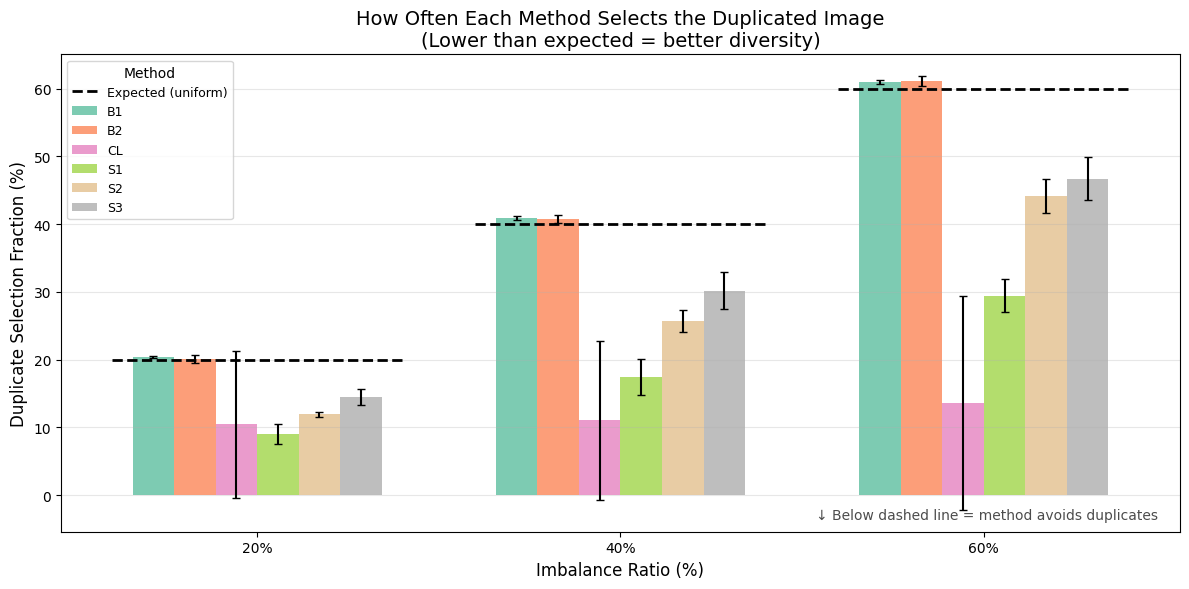


Deviation from Expected (negative = selects duplicates LESS than expected):


,method,ratio,dup_frac_mean,expected_frac,deviation_from_expected
9,S1,20,0.090500,0.2,-10.950000
6,CL,20,0.104567,0.2,-9.543333
12,S2,20,0.119433,0.2,-8.056667
15,S3,20,0.144467,0.2,-5.553333
3,B2,20,0.200700,0.2,0.070000
0,B1,20,0.204167,0.2,0.416667
7,CL,40,0.110467,0.4,-28.953333
10,S1,40,0.174467,0.4,-22.553333
13,S2,40,0.257200,0.4,-14.280000
16,S3,40,0.301900,0.4,-9.810000


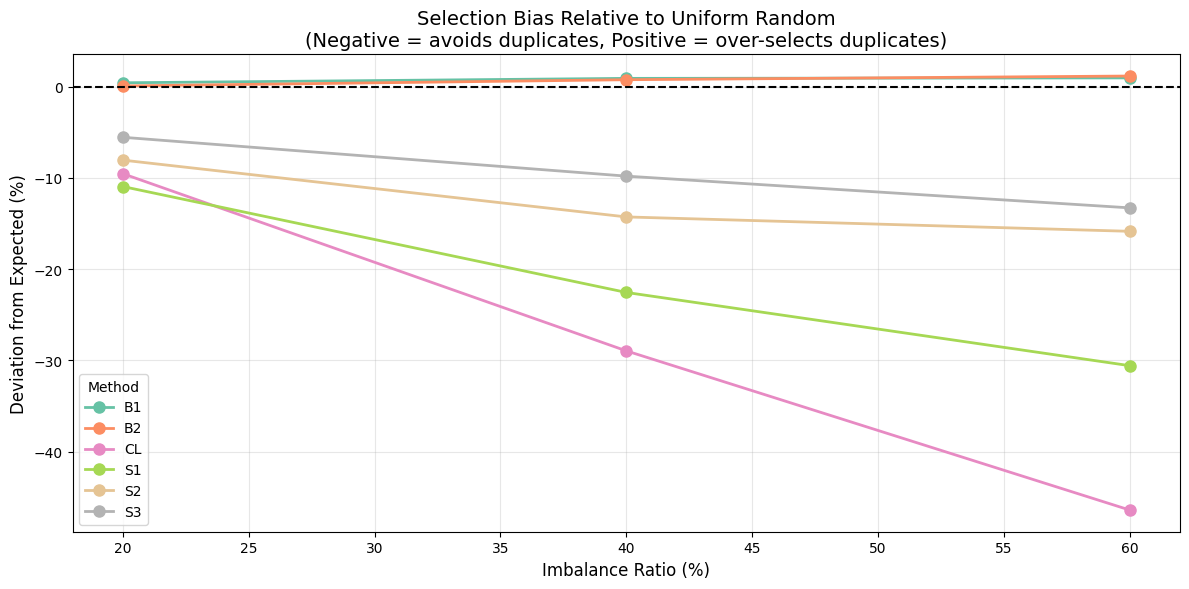

In [14]:
# =========================================================================
# DUPLICATE SELECTION ANALYSIS
# Compare how often each method selects the duplicated image vs expected
# =========================================================================

def compute_dup_selection_stats(run_dir: Path) -> Dict[str, Any]:
    """Compute selection statistics for duplicate images."""
    p = run_dir / "selection_history.jsonl"
    if not p.exists():
        return {}
    
    total = 0
    dup_count = 0
    for rec in read_jsonl(p):
        name = rec.get("cam_name", "")
        if not name:
            continue
        total += 1
        if "__dup" in str(name):
            dup_count += 1
    
    if total == 0:
        return {}
    
    return {
        "total_selections": total,
        "dup_selections": dup_count,
        "dup_fraction": dup_count / total,
    }


# Compute duplicate selection stats for all runs
dup_stats_rows = []
for r in runs:
    stats = compute_dup_selection_stats(r.run_dir)
    if not stats:
        continue
    
    dup_stats_rows.append({
        "method": r.method,
        "scene": r.scene,
        "base_scene_id": r.base_scene_id,
        "ratio": r.ratio,
        "seed": r.seed,
        **stats,
    })

dup_stats = pd.DataFrame(dup_stats_rows)

if len(dup_stats) > 0:
    dup_stats["ratio"] = pd.to_numeric(dup_stats["ratio"], errors="coerce").astype(int)
    
    # Aggregate by method and ratio
    dup_agg = dup_stats.groupby(["method", "ratio"]).agg({
        "dup_fraction": ["mean", "std"],
        "total_selections": "mean",
    }).reset_index()
    dup_agg.columns = ["method", "ratio", "dup_frac_mean", "dup_frac_std", "avg_selections"]
    
    print("Duplicate Selection Fraction by Method and Ratio:")
    display(dup_agg.sort_values(["ratio", "method"]))
    
    # =========================================================================
    # BAR CHART: Duplicate selection fraction vs expected (ratio)
    # =========================================================================
    ratios = sorted(dup_agg["ratio"].unique())
    methods = sorted(dup_agg["method"].unique())
    n_methods = len(methods)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(ratios))
    bar_width = 0.8 / (n_methods + 1)  # +1 for expected line
    colors = plt.cm.Set2(np.linspace(0, 1, n_methods))
    
    for i, method in enumerate(methods):
        method_data = dup_agg[dup_agg["method"] == method].set_index("ratio")
        means = [method_data.loc[r, "dup_frac_mean"] * 100 if r in method_data.index else 0 for r in ratios]
        stds = [method_data.loc[r, "dup_frac_std"] * 100 if r in method_data.index else 0 for r in ratios]
        offset = (i - n_methods / 2 + 0.5) * bar_width
        ax.bar(x + offset, means, bar_width, label=method, color=colors[i],
               yerr=stds, capsize=3, alpha=0.85)
    
    # Add expected line (duplicate fraction = ratio if random)
    for j, r in enumerate(ratios):
        ax.plot([j - 0.4, j + 0.4], [r, r], 'k--', linewidth=2, 
                label="Expected (uniform)" if j == 0 else None)
    
    ax.set_xlabel("Imbalance Ratio (%)", fontsize=12)
    ax.set_ylabel("Duplicate Selection Fraction (%)", fontsize=12)
    ax.set_title("How Often Each Method Selects the Duplicated Image\n(Lower than expected = better diversity)", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r}%" for r in ratios])
    ax.legend(title="Method", loc="upper left", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    
    # Annotation
    ax.annotate("↓ Below dashed line = method avoids duplicates", xy=(0.98, 0.02),
               xycoords="axes fraction", fontsize=10, ha="right", va="bottom", alpha=0.7)
    
    plt.tight_layout()
    savefig("dup_selection_vs_expected.png")
    plt.show()
    
    # =========================================================================
    # DEVIATION FROM EXPECTED: How much better/worse than random?
    # =========================================================================
    dup_agg["expected_frac"] = dup_agg["ratio"] / 100  # ratio is percentage
    dup_agg["deviation_from_expected"] = (dup_agg["dup_frac_mean"] - dup_agg["expected_frac"]) * 100
    
    print("\nDeviation from Expected (negative = selects duplicates LESS than expected):")
    display(dup_agg[["method", "ratio", "dup_frac_mean", "expected_frac", "deviation_from_expected"]]
            .sort_values(["ratio", "deviation_from_expected"]))
    
    # Plot deviation
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for i, method in enumerate(methods):
        method_data = dup_agg[dup_agg["method"] == method].sort_values("ratio")
        ax.plot(method_data["ratio"], method_data["deviation_from_expected"], 
                marker="o", markersize=8, linewidth=2, label=method, color=colors[i])
    
    ax.axhline(0, color="black", linewidth=1.5, linestyle="--")
    ax.set_xlabel("Imbalance Ratio (%)", fontsize=12)
    ax.set_ylabel("Deviation from Expected (%)", fontsize=12)
    ax.set_title("Selection Bias Relative to Uniform Random\n(Negative = avoids duplicates, Positive = over-selects duplicates)", fontsize=14)
    ax.legend(title="Method", loc="best")
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    savefig("dup_selection_deviation.png")
    plt.show()
else:
    print("No duplicate selection data available.")

## 10. Load cameras.json and build camera selection summary

We use:
- `cameras.json` for camera metadata (position/rotation per `id`, plus `img_name`).
- `selection_history.jsonl` for the actual per-iteration selections.

We build a per-run table of selection counts + per-run summary stats.

In [15]:
def load_cameras(run_dir: Path) -> Optional[pd.DataFrame]:
    p = run_dir / "cameras.json"
    if not p.exists():
        return None
    try:
        data = read_json(p)
    except Exception as e:
        warnings.warn(f"Failed reading {p}: {e}")
        return None
    if not isinstance(data, list):
        return None
    rows = []
    for c in data:
        if not isinstance(c, dict):
            continue
        rows.append(
            {
                "cam_uid": c.get("id"),
                "cam_name": c.get("img_name"),
                "position": c.get("position"),
            }
        )
    df = pd.DataFrame(rows)
    df["cam_uid"] = pd.to_numeric(df["cam_uid"], errors="coerce")
    return df


def selection_counts(run_dir: Path) -> Tuple[Counter, int]:
    p = run_dir / "selection_history.jsonl"
    if not p.exists():
        return Counter(), 0
    ctr = Counter()
    n = 0
    for rec in read_jsonl(p):
        name = rec.get("cam_name")
        if not name:
            continue
        ctr[str(name)] += 1
        n += 1
    return ctr, n


sel_rows = []
sel_summary_rows = []
for r in runs:
    ctr, n_steps = selection_counts(r.run_dir)
    cams = load_cameras(r.run_dir)

    # per-run summary
    total = sum(ctr.values())
    dup = sum(v for k, v in ctr.items() if "__dup" in k)
    dup_frac = (dup / total) if total > 0 else float("nan")

    top10 = ctr.most_common(10)
    sel_summary_rows.append(
        {
            "method": r.method,
            "scene": r.scene,
            "base_scene_id": r.base_scene_id,
            "ratio": r.ratio,
            "seed": r.seed,
            "run_id": f"{r.method}/{r.scene}/seed{r.seed}",
            "num_steps": n_steps,
            "num_unique": len(ctr),
            "dup_selection_fraction": dup_frac,
            "top10": json.dumps(top10),
            "run_dir": str(r.run_dir),
        }
    )

    # optional per-camera table (can be large; keep only if needed later)
    for cam_name, count in ctr.items():
        sel_rows.append(
            {
                "method": r.method,
                "scene": r.scene,
                "base_scene_id": r.base_scene_id,
                "ratio": r.ratio,
                "seed": r.seed,
                "cam_name": cam_name,
                "count": count,
                "is_dup": "__dup" in cam_name,
            }
        )

selection_summary = pd.DataFrame(sel_summary_rows)
selection_per_camera = pd.DataFrame(sel_rows)

selection_summary_path = NOTEBOOK_OUTPUTS_DIR / "camera_selection_summary_per_run.csv"
selection_summary.to_csv(selection_summary_path, index=False)
print("Wrote:", selection_summary_path.resolve())

selection_summary.head()

Wrote: /home/fgrob/gaussian-splatting/notebook_outputs/ablation_imbalanced_sanity_v1_analysis/camera_selection_summary_per_run.csv


,method,scene,base_scene_id,ratio,seed,run_id,num_steps,num_unique,dup_selection_fraction,top10,run_dir
0,B1,0c5385e84b_imb20_rand1,0c5385e84b,20,0,B1/0c5385e84b_imb20_rand1/seed0,10000,210,0.2049,"[[""DSC03874__dup0021"", 48], [""DSC03735"", 48], ...",/home/fgrob/gaussian-splatting/output/ablation...
1,B1,0c5385e84b_imb40_rand1,0c5385e84b,40,0,B1/0c5385e84b_imb40_rand1/seed0,10000,284,0.4120,"[[""DSC03794"", 36], [""DSC03793"", 36], [""DSC0387...",/home/fgrob/gaussian-splatting/output/ablation...
2,B1,0c5385e84b_imb60_rand1,0c5385e84b,60,0,B1/0c5385e84b_imb60_rand1/seed0,10000,430,0.6124,"[[""DSC03784"", 24], [""DSC03874__dup0112"", 24], ...",/home/fgrob/gaussian-splatting/output/ablation...
3,B1,5371eff4f9_imb20_rand1,5371eff4f9,20,0,B1/5371eff4f9_imb20_rand1/seed0,10000,288,0.2048,"[[""DSC04727"", 35], [""DSC04725"", 35], [""DSC0472...",/home/fgrob/gaussian-splatting/output/ablation...
4,B1,5371eff4f9_imb40_rand1,5371eff4f9,40,0,B1/5371eff4f9_imb40_rand1/seed0,10000,387,0.4085,"[[""DSC04882"", 26], [""DSC04887__dup0154"", 26], ...",/home/fgrob/gaussian-splatting/output/ablation...


## 11. Selection Distribution Analysis (Entropy, Coverage, Effective Sample Size)

Inspired by `examples/analyze_ablation_selection.py`, we analyze the realized selection distribution:

| Metric | Description | Interpretation |
|--------|-------------|----------------|
| **Coverage** | Fraction of available cameras ever selected | Higher = explores more views |
| **Normalized Entropy** | $H/\log(K)$ where $H$ is Shannon entropy | 1.0 = uniform, 0 = concentrated |
| **Gini Coefficient** | Inequality measure | 0 = equal, 1 = all mass on one item |
| **Effective Sample Size (ESS)** | $1/\sum p_i^2$ | ~K for uniform, small for concentrated |
| **Top-k Share** | Fraction of selections in top-k cameras | Lower = more diverse |

**Hypothesis**: Smart selection methods should have **higher entropy/ESS** and **lower Gini/top-k** than baselines on imbalanced data.

In [16]:
def entropy(p: np.ndarray) -> float:
    p = p[p > 0]
    if len(p) == 0:
        return float("nan")
    return float(-(p * np.log(p)).sum())


def gini(counts: np.ndarray) -> float:
    x = counts.astype(float)
    x = x[x >= 0]
    if len(x) == 0:
        return float("nan")
    if x.sum() == 0:
        return 0.0
    x = np.sort(x)
    n = len(x)
    # G = (2 * sum_i i*x_i)/(n*sum x) - (n+1)/n
    i = np.arange(1, n + 1)
    return float((2.0 * (i * x).sum()) / (n * x.sum()) - (n + 1) / n)


def topk_share(counts: np.ndarray, k: int) -> float:
    if len(counts) == 0:
        return float("nan")
    total = counts.sum()
    if total <= 0:
        return float("nan")
    k = min(int(k), len(counts))
    return float(np.sort(counts)[-k:].sum() / total)


def effective_sample_size_from_counts(counts: np.ndarray) -> float:
    counts = counts.astype(np.float64)
    s = float(counts.sum())
    if s <= 0:
        return float("nan")
    p = counts / s
    denom = float((p * p).sum())
    return float(1.0 / denom) if denom > 0 else float("nan")


def load_selection_history(run_dir: Path) -> pd.DataFrame:
    p = run_dir / "selection_history.jsonl"
    if not p.exists():
        return pd.DataFrame()
    rows = []
    for rec in read_jsonl(p):
        it = rec.get("iteration")
        uid = rec.get("cam_uid")
        name = rec.get("cam_name")
        prob = rec.get("probability")
        if it is None or uid is None:
            continue
        row = {"iteration": int(it), "cam_uid": int(uid)}
        if name is not None:
            row["cam_name"] = str(name)
            row["is_dup"] = "__dup" in str(name)
        if prob is not None:
            try:
                row["probability"] = float(prob)
            except Exception:
                pass
        rows.append(row)
    return pd.DataFrame(rows)


num_train_by_run_id = {}
if "run_id" in metrics_per_run.columns and "num_train" in metrics_per_run.columns:
    num_train_by_run_id = (
        metrics_per_run.dropna(subset=["run_id"]).set_index("run_id")["num_train"].to_dict()
    )


stats_rows = []
prob_ts_rows = []  # for later plots (selected prob vs iteration)
for _, r in selection_summary.iterrows():
    run_dir = Path(r["run_dir"])
    run_id = r["run_id"]
    ctr, _ = selection_counts(run_dir)
    counts = np.array(list(ctr.values()), dtype=float)
    if counts.sum() <= 0:
        continue
    p = counts / counts.sum()
    H = entropy(p)
    K = len(p)
    Hn = H / math.log(K) if K > 1 else 0.0

    # Split size for uniform-prob diagnostics
    n_train = num_train_by_run_id.get(run_id)
    try:
        n_train = int(n_train) if (n_train is not None and not pd.isna(n_train)) else None
    except Exception:
        n_train = None
    uniform_prob = (1.0 / n_train) if (n_train and n_train > 0) else float("nan")
    coverage = (float(r["num_unique"]) / float(n_train)) if (n_train and n_train > 0) else float("nan")

    # Probability diagnostics (selected prob at each iteration)
    df_sel = load_selection_history(run_dir)
    n_steps = int(len(df_sel)) if len(df_sel) else int(r.get("num_steps", 0))
    mean_prob = float(df_sel["probability"].mean()) if (len(df_sel) and "probability" in df_sel.columns) else float("nan")
    std_prob = float(df_sel["probability"].std()) if (len(df_sel) and "probability" in df_sel.columns) else float("nan")
    min_prob = float(df_sel["probability"].min()) if (len(df_sel) and "probability" in df_sel.columns) else float("nan")
    max_prob = float(df_sel["probability"].max()) if (len(df_sel) and "probability" in df_sel.columns) else float("nan")
    p05 = float(df_sel["probability"].quantile(0.05)) if (len(df_sel) and "probability" in df_sel.columns) else float("nan")
    p50 = float(df_sel["probability"].quantile(0.50)) if (len(df_sel) and "probability" in df_sel.columns) else float("nan")
    p95 = float(df_sel["probability"].quantile(0.95)) if (len(df_sel) and "probability" in df_sel.columns) else float("nan")

    # If probabilities sum to 1 per-iteration, E[p_selected] = sum_i p_i^2. Then 1/E[p_selected] ~ effective #cameras.
    prob_eff_n = (1.0 / mean_prob) if (mean_prob and not np.isnan(mean_prob) and mean_prob > 0) else float("nan")
    prob_eff_frac = (prob_eff_n / float(n_train)) if (n_train and n_train > 0 and not np.isnan(prob_eff_n)) else float("nan")

    frac_gt_2x = float("nan")
    frac_gt_5x = float("nan")
    if len(df_sel) and "probability" in df_sel.columns and n_train and n_train > 0:
        probs = df_sel["probability"].to_numpy(dtype=float)
        frac_gt_2x = float(np.mean(probs > 2.0 * uniform_prob))
        frac_gt_5x = float(np.mean(probs > 5.0 * uniform_prob))
        # keep timeseries for plots
        df_tmp = df_sel[["iteration", "probability"]].copy()
        df_tmp["method"] = r["method"]
        df_tmp["base_scene_id"] = r["base_scene_id"]
        df_tmp["ratio"] = r["ratio"]
        df_tmp["seed"] = r["seed"]
        df_tmp["n_train"] = n_train
        prob_ts_rows.append(df_tmp)

    stats_rows.append(
        {
            "run_id": run_id,
            "method": r["method"],
            "base_scene_id": r["base_scene_id"],
            "ratio": r["ratio"],
            "seed": r["seed"],
            "num_steps": n_steps,
            "num_unique": r["num_unique"],
            "coverage_vs_train": coverage,
            "entropy": H,
            "entropy_norm": Hn,
            "gini": gini(counts),
            "ess": effective_sample_size_from_counts(counts),
            "top1_share": topk_share(counts, 1),
            "top5_share": topk_share(counts, 5),
            "top10_share": topk_share(counts, 10),
            "dup_selection_fraction": r["dup_selection_fraction"],
            "mean_selected_prob": mean_prob,
            "std_selected_prob": std_prob,
            "min_selected_prob": min_prob,
            "p05_selected_prob": p05,
            "p50_selected_prob": p50,
            "p95_selected_prob": p95,
            "max_selected_prob": max_prob,
            "uniform_prob": uniform_prob,
            "prob_eff_num_cameras": prob_eff_n,
            "prob_eff_fraction_of_total": prob_eff_frac,
            "frac_selected_prob_gt_2x_uniform": frac_gt_2x,
            "frac_selected_prob_gt_5x_uniform": frac_gt_5x,
        }
    )

selection_stats = pd.DataFrame(stats_rows)
selection_stats_path = NOTEBOOK_OUTPUTS_DIR / "camera_selection_stats.csv"
selection_stats.to_csv(selection_stats_path, index=False)
print("Wrote:", selection_stats_path.resolve())

selection_prob_timeseries = pd.concat(prob_ts_rows, ignore_index=True) if prob_ts_rows else pd.DataFrame()
if len(selection_prob_timeseries) > 0:
    p_ts_path = NOTEBOOK_OUTPUTS_DIR / "selected_probability_timeseries.csv"
    selection_prob_timeseries.to_csv(p_ts_path, index=False)
    print("Wrote:", p_ts_path.resolve())

selection_stats.head()

Wrote: /home/fgrob/gaussian-splatting/notebook_outputs/ablation_imbalanced_sanity_v1_analysis/camera_selection_stats.csv
Wrote: /home/fgrob/gaussian-splatting/notebook_outputs/ablation_imbalanced_sanity_v1_analysis/selected_probability_timeseries.csv


,run_id,method,base_scene_id,ratio,seed,num_steps,num_unique,coverage_vs_train,entropy,entropy_norm,...,min_selected_prob,p05_selected_prob,p50_selected_prob,p95_selected_prob,max_selected_prob,uniform_prob,prob_eff_num_cameras,prob_eff_fraction_of_total,frac_selected_prob_gt_2x_uniform,frac_selected_prob_gt_5x_uniform
0,B1/0c5385e84b_imb20_rand1/seed0,B1,0c5385e84b,20,0,10000,210,1.0,5.347055,0.999990,...,0.004762,0.004762,0.004762,0.004762,0.004762,0.004762,210.0,1.0,0.0,0.0
1,B1/0c5385e84b_imb40_rand1/seed0,B1,0c5385e84b,40,0,10000,284,1.0,5.648907,0.999988,...,0.003521,0.003521,0.003521,0.003521,0.003521,0.003521,284.0,1.0,0.0,0.0
2,B1/0c5385e84b_imb60_rand1/seed0,B1,0c5385e84b,60,0,10000,430,1.0,6.063610,0.999971,...,0.002326,0.002326,0.002326,0.002326,0.002326,0.002326,430.0,1.0,0.0,0.0
3,B1/5371eff4f9_imb20_rand1/seed0,B1,5371eff4f9,20,0,10000,288,1.0,5.662877,0.999985,...,0.003472,0.003472,0.003472,0.003472,0.003472,0.003472,288.0,1.0,0.0,0.0
4,B1/5371eff4f9_imb40_rand1/seed0,B1,5371eff4f9,40,0,10000,387,1.0,5.958323,0.999983,...,0.002584,0.002584,0.002584,0.002584,0.002584,0.002584,387.0,1.0,0.0,0.0


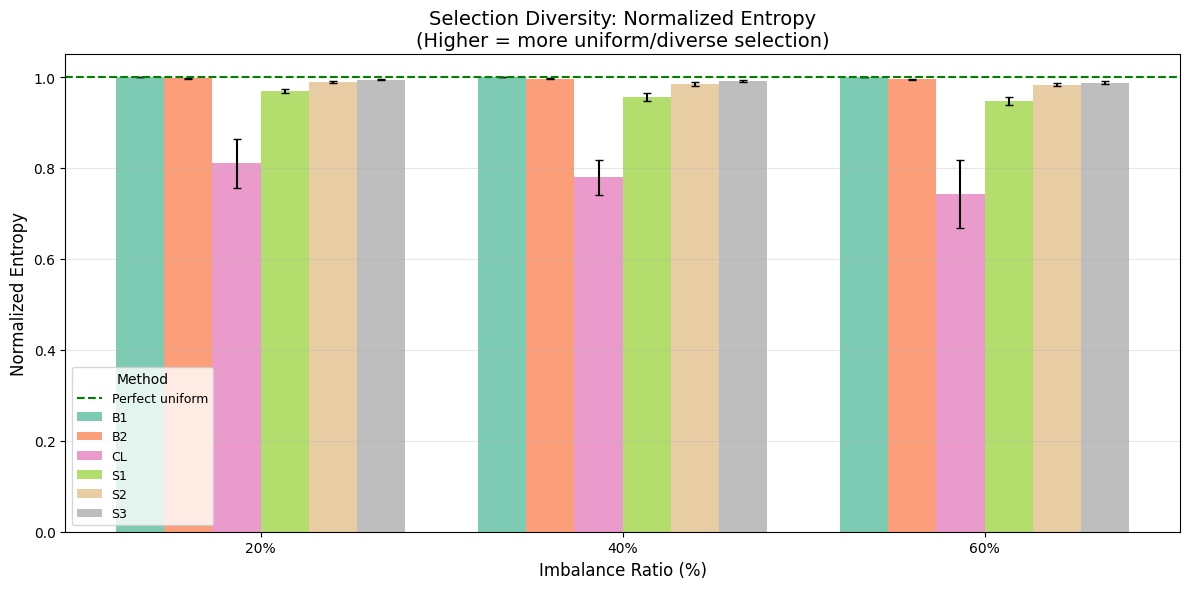

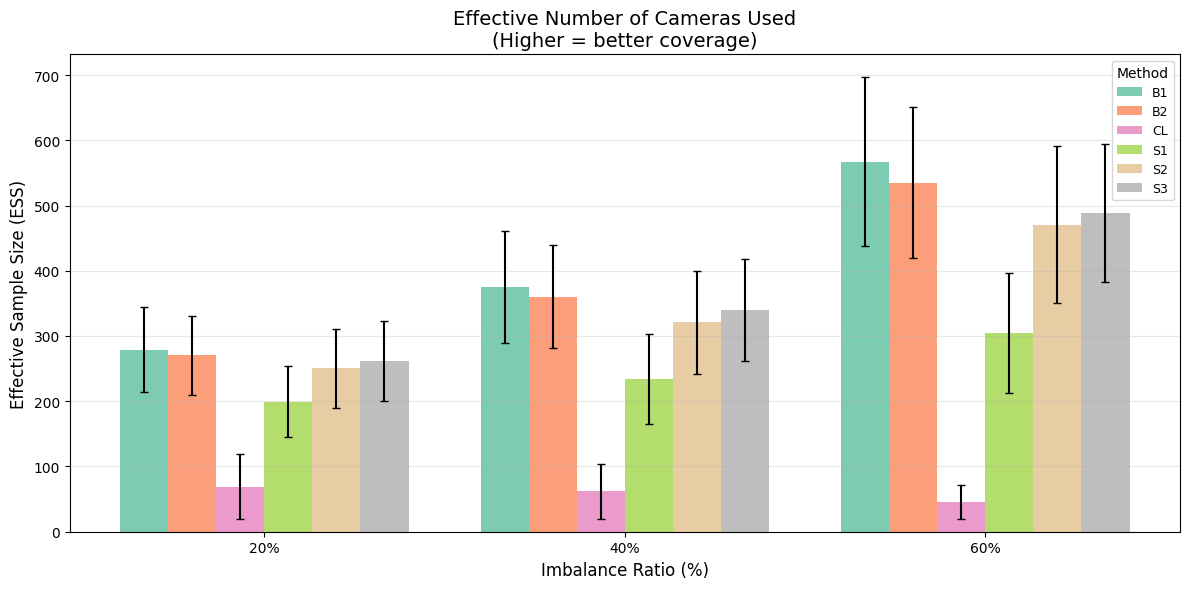

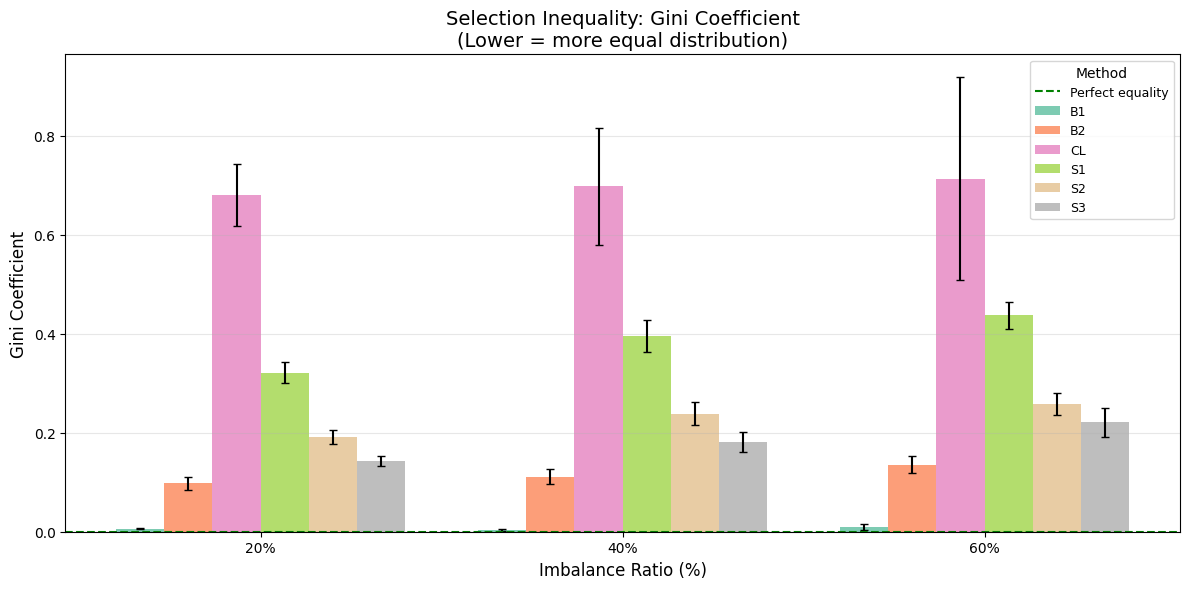

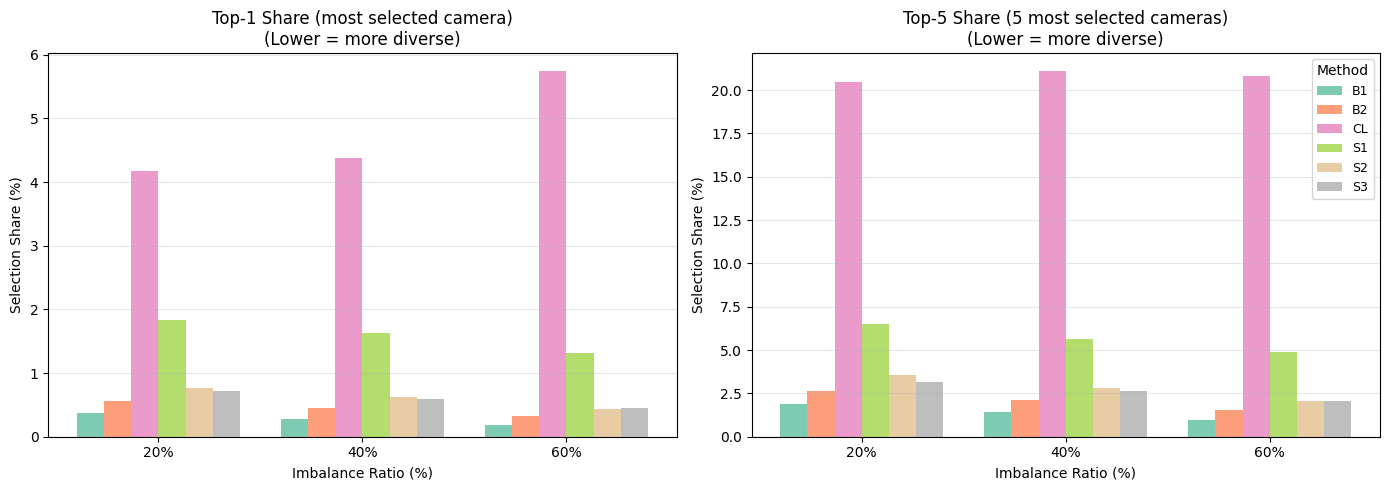

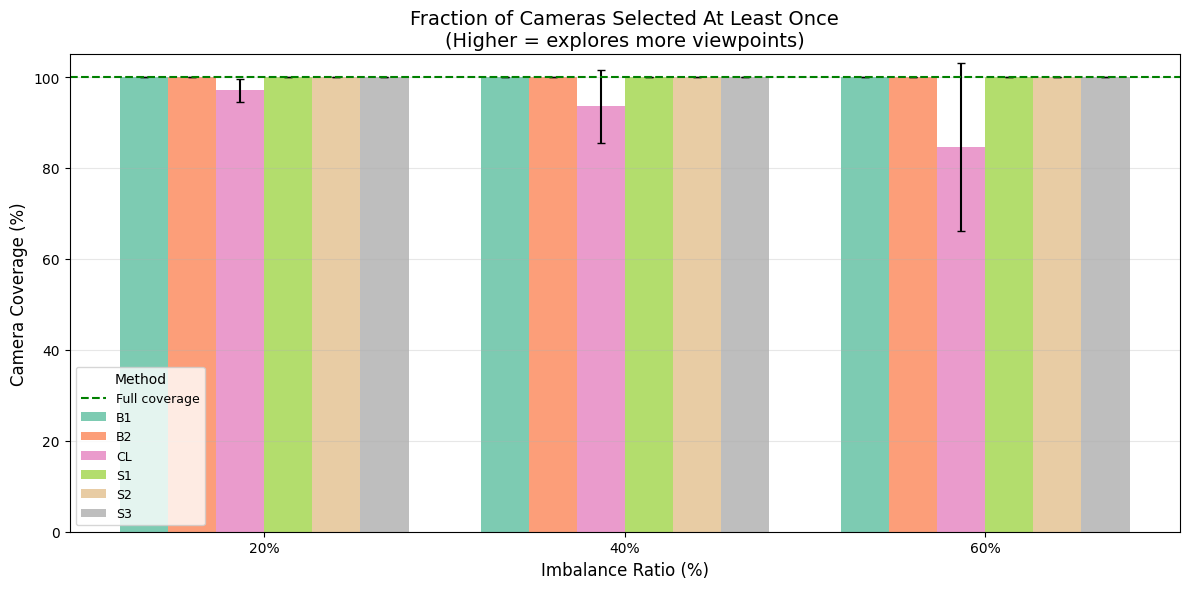

In [17]:
# =========================================================================
# SELECTION DISTRIBUTION: Bar charts comparing methods
# =========================================================================

if len(selection_stats) > 0:
    # Aggregate selection stats by method and ratio
    sel_agg = selection_stats.groupby(["method", "ratio"]).agg({
        "entropy_norm": ["mean", "std"],
        "gini": ["mean", "std"],
        "ess": ["mean", "std"],
        "top1_share": ["mean", "std"],
        "top5_share": ["mean", "std"],
        "coverage_vs_train": ["mean", "std"],
        "dup_selection_fraction": ["mean", "std"],
    }).reset_index()
    
    # Flatten column names
    sel_agg.columns = ["_".join(col).strip("_") if col[1] else col[0] 
                       for col in sel_agg.columns]
    sel_agg["ratio"] = pd.to_numeric(sel_agg["ratio"], errors="coerce").astype(int)
    
    methods = sorted(sel_agg["method"].unique())
    ratios = sorted(sel_agg["ratio"].unique())
    n_methods = len(methods)
    colors = plt.cm.Set2(np.linspace(0, 1, n_methods))
    
    # =========================================================================
    # 1. NORMALIZED ENTROPY: Higher = more diverse selection
    # =========================================================================
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(ratios))
    bar_width = 0.8 / n_methods
    
    for i, method in enumerate(methods):
        method_data = sel_agg[sel_agg["method"] == method].set_index("ratio")
        means = [method_data.loc[r, "entropy_norm_mean"] if r in method_data.index else 0 for r in ratios]
        stds = [method_data.loc[r, "entropy_norm_std"] if r in method_data.index else 0 for r in ratios]
        offset = (i - n_methods / 2 + 0.5) * bar_width
        ax.bar(x + offset, means, bar_width, label=method, color=colors[i],
               yerr=stds, capsize=3, alpha=0.85)
    
    ax.axhline(1.0, color="green", linewidth=1.5, linestyle="--", label="Perfect uniform")
    ax.set_xlabel("Imbalance Ratio (%)", fontsize=12)
    ax.set_ylabel("Normalized Entropy", fontsize=12)
    ax.set_title("Selection Diversity: Normalized Entropy\n(Higher = more uniform/diverse selection)", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r}%" for r in ratios])
    ax.legend(title="Method", loc="best", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 1.05)
    
    plt.tight_layout()
    savefig("selection_entropy_bar.png")
    plt.show()
    
    # =========================================================================
    # 2. EFFECTIVE SAMPLE SIZE: How many cameras are "effectively" being used?
    # =========================================================================
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for i, method in enumerate(methods):
        method_data = sel_agg[sel_agg["method"] == method].set_index("ratio")
        means = [method_data.loc[r, "ess_mean"] if r in method_data.index else 0 for r in ratios]
        stds = [method_data.loc[r, "ess_std"] if r in method_data.index else 0 for r in ratios]
        offset = (i - n_methods / 2 + 0.5) * bar_width
        ax.bar(x + offset, means, bar_width, label=method, color=colors[i],
               yerr=stds, capsize=3, alpha=0.85)
    
    ax.set_xlabel("Imbalance Ratio (%)", fontsize=12)
    ax.set_ylabel("Effective Sample Size (ESS)", fontsize=12)
    ax.set_title("Effective Number of Cameras Used\n(Higher = better coverage)", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r}%" for r in ratios])
    ax.legend(title="Method", loc="best", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    
    plt.tight_layout()
    savefig("selection_ess_bar.png")
    plt.show()
    
    # =========================================================================
    # 3. GINI COEFFICIENT: Lower = more equal distribution
    # =========================================================================
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for i, method in enumerate(methods):
        method_data = sel_agg[sel_agg["method"] == method].set_index("ratio")
        means = [method_data.loc[r, "gini_mean"] if r in method_data.index else 0 for r in ratios]
        stds = [method_data.loc[r, "gini_std"] if r in method_data.index else 0 for r in ratios]
        offset = (i - n_methods / 2 + 0.5) * bar_width
        ax.bar(x + offset, means, bar_width, label=method, color=colors[i],
               yerr=stds, capsize=3, alpha=0.85)
    
    ax.axhline(0.0, color="green", linewidth=1.5, linestyle="--", label="Perfect equality")
    ax.set_xlabel("Imbalance Ratio (%)", fontsize=12)
    ax.set_ylabel("Gini Coefficient", fontsize=12)
    ax.set_title("Selection Inequality: Gini Coefficient\n(Lower = more equal distribution)", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r}%" for r in ratios])
    ax.legend(title="Method", loc="best", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    
    plt.tight_layout()
    savefig("selection_gini_bar.png")
    plt.show()
    
    # =========================================================================
    # 4. TOP-K SHARE: What fraction goes to the top cameras?
    # =========================================================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax, (metric, title) in zip(axes, [
        ("top1_share_mean", "Top-1 Share (most selected camera)"),
        ("top5_share_mean", "Top-5 Share (5 most selected cameras)")
    ]):
        for i, method in enumerate(methods):
            method_data = sel_agg[sel_agg["method"] == method].set_index("ratio")
            means = [method_data.loc[r, metric] * 100 if r in method_data.index else 0 for r in ratios]
            offset = (i - n_methods / 2 + 0.5) * bar_width
            ax.bar(x + offset, means, bar_width, label=method, color=colors[i], alpha=0.85)
        
        ax.set_xlabel("Imbalance Ratio (%)")
        ax.set_ylabel("Selection Share (%)")
        ax.set_title(title + "\n(Lower = more diverse)")
        ax.set_xticks(x)
        ax.set_xticklabels([f"{r}%" for r in ratios])
        ax.grid(axis="y", alpha=0.3)
    
    axes[-1].legend(title="Method", loc="best", fontsize=9)
    plt.tight_layout()
    savefig("selection_topk_share_bar.png")
    plt.show()
    
    # =========================================================================
    # 5. COVERAGE: What fraction of cameras were selected at least once?
    # =========================================================================
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for i, method in enumerate(methods):
        method_data = sel_agg[sel_agg["method"] == method].set_index("ratio")
        means = [method_data.loc[r, "coverage_vs_train_mean"] * 100 if r in method_data.index else 0 for r in ratios]
        stds = [method_data.loc[r, "coverage_vs_train_std"] * 100 if r in method_data.index else 0 for r in ratios]
        offset = (i - n_methods / 2 + 0.5) * bar_width
        ax.bar(x + offset, means, bar_width, label=method, color=colors[i],
               yerr=stds, capsize=3, alpha=0.85)
    
    ax.axhline(100.0, color="green", linewidth=1.5, linestyle="--", label="Full coverage")
    ax.set_xlabel("Imbalance Ratio (%)", fontsize=12)
    ax.set_ylabel("Camera Coverage (%)", fontsize=12)
    ax.set_title("Fraction of Cameras Selected At Least Once\n(Higher = explores more viewpoints)", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r}%" for r in ratios])
    ax.legend(title="Method", loc="best", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 105)
    
    plt.tight_layout()
    savefig("selection_coverage_bar.png")
    plt.show()
    
else:
    print("No selection_stats available.")

--- Selection Count Distribution per Camera ---


/tmp/ipykernel_846039/3775426322.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_boxplot, labels=methods_in_data, patch_artist=True,


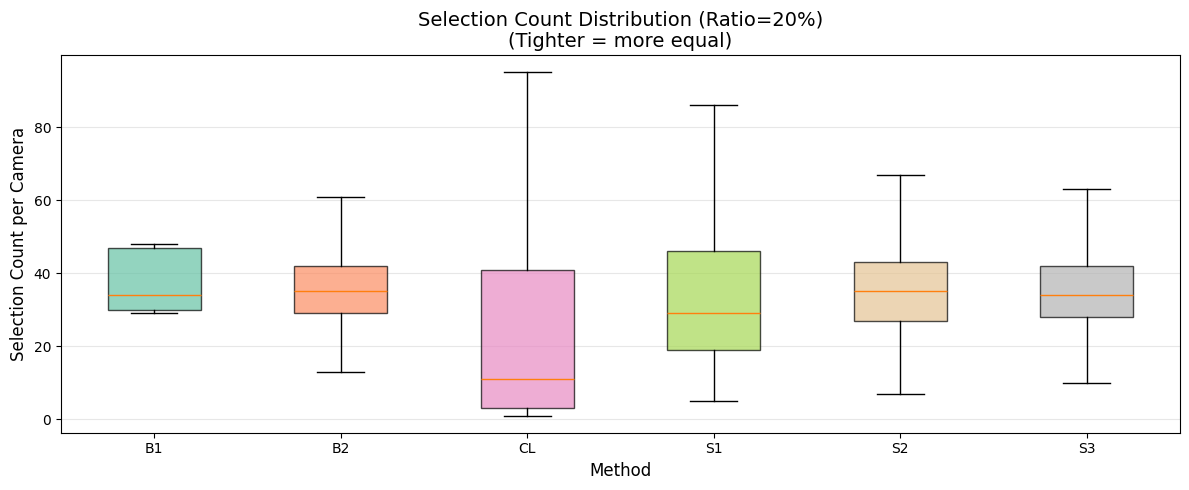

/tmp/ipykernel_846039/3775426322.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_boxplot, labels=methods_in_data, patch_artist=True,


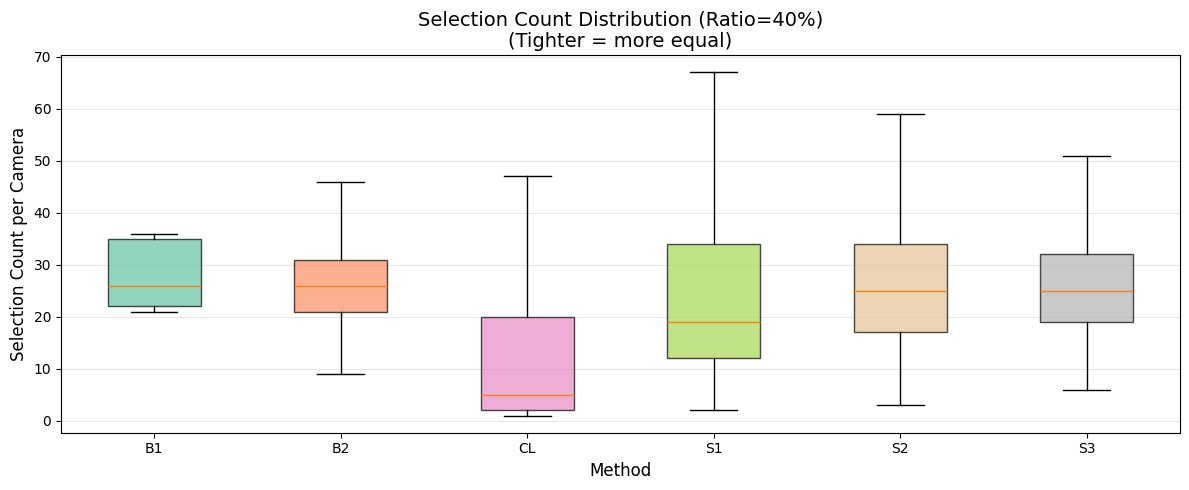

/tmp/ipykernel_846039/3775426322.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_boxplot, labels=methods_in_data, patch_artist=True,


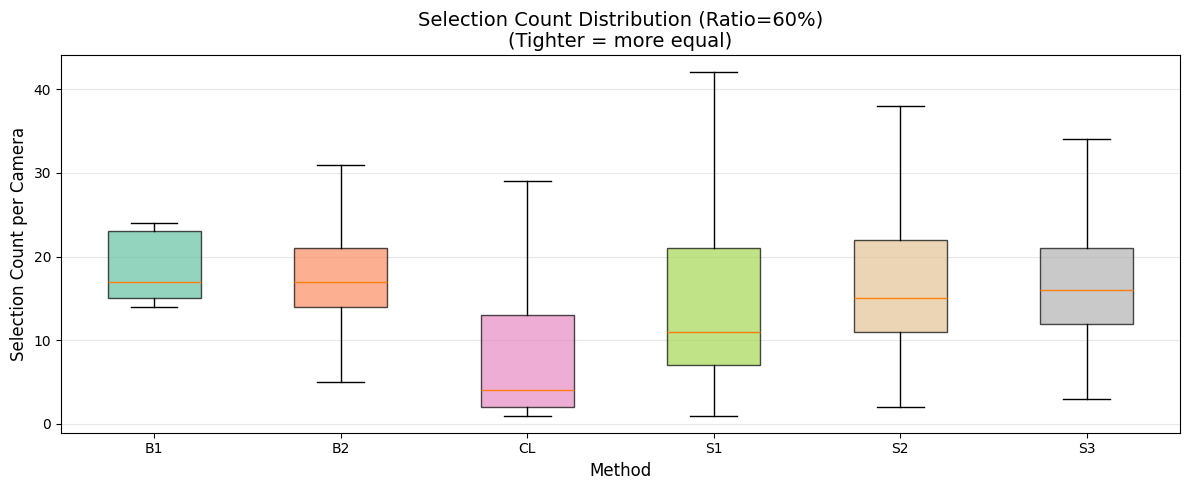


--- Duplicate vs Non-Duplicate Selection Comparison ---
Average selection count: Duplicates vs Non-duplicates


,method,ratio,non_dup_avg,dup_avg,dup_vs_nondup_ratio
0,B1,20,35.848348,35.818713,0.999173
3,B2,20,36.004505,35.210526,0.977948
6,CL,20,42.039124,18.452941,0.438947
9,S1,20,40.968468,15.877193,0.387547
12,S2,20,39.665165,20.953216,0.528252
15,S3,20,38.537538,25.345029,0.657671
1,B1,40,26.621622,26.673913,1.001964
4,B2,40,26.687688,26.578261,0.995900
7,CL,40,42.561404,8.004831,0.188077
10,S1,40,37.186186,11.378261,0.305981


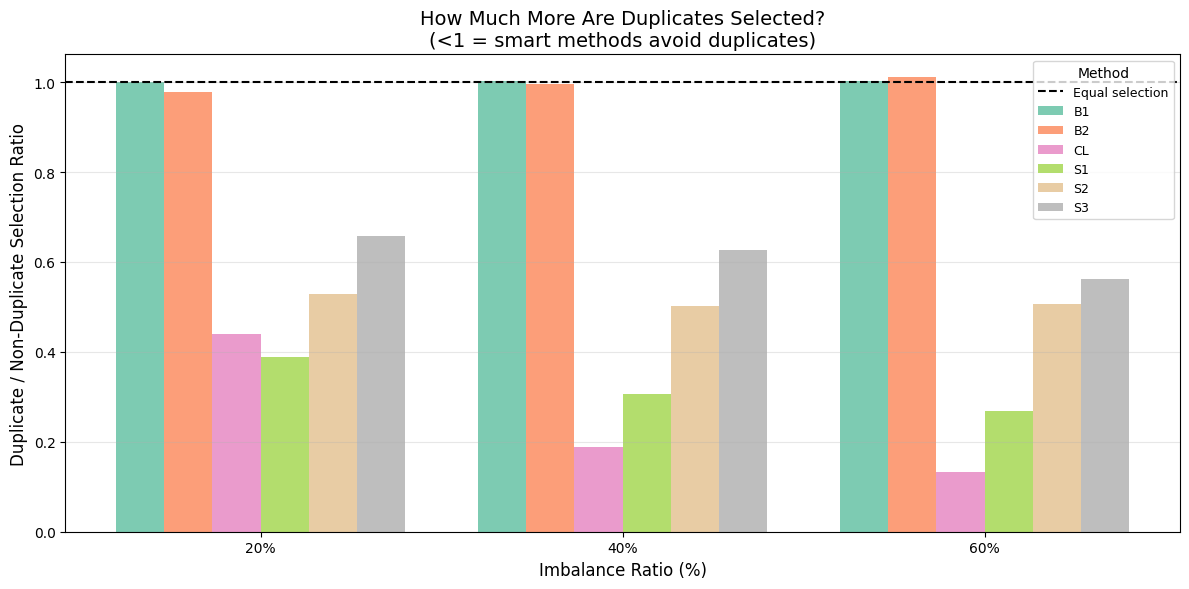

In [18]:
# =========================================================================
# SELECTION COUNT DISTRIBUTION: Histogram/boxplot of per-camera selection counts
# This shows how evenly selections are distributed across cameras
# =========================================================================

if len(selection_per_camera) > 0:
    print("--- Selection Count Distribution per Camera ---")
    
    # For each ratio, show boxplot of selection counts across methods
    for ratio in sorted(selection_per_camera["ratio"].dropna().unique()):
        ratio_data = selection_per_camera[
            pd.to_numeric(selection_per_camera["ratio"], errors="coerce") == ratio
        ].copy()
        
        if len(ratio_data) == 0:
            continue
        
        fig, ax = plt.subplots(figsize=(12, 5))
        
        methods_in_data = sorted(ratio_data["method"].unique())
        data_for_boxplot = [
            ratio_data[ratio_data["method"] == m]["count"].values
            for m in methods_in_data
        ]
        
        bp = ax.boxplot(data_for_boxplot, labels=methods_in_data, patch_artist=True, 
                        showfliers=False)
        
        colors_box = plt.cm.Set2(np.linspace(0, 1, len(methods_in_data)))
        for patch, color in zip(bp["boxes"], colors_box):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_xlabel("Method", fontsize=12)
        ax.set_ylabel("Selection Count per Camera", fontsize=12)
        ax.set_title(f"Selection Count Distribution (Ratio={int(ratio)}%)\n(Tighter = more equal)", fontsize=14)
        ax.grid(axis="y", alpha=0.3)
        
        plt.tight_layout()
        savefig(f"selection_count_boxplot_r{int(ratio)}.png")
        plt.show()
    
    # =========================================================================
    # DUPLICATE vs NON-DUPLICATE: Compare selection counts
    # =========================================================================
    print("\n--- Duplicate vs Non-Duplicate Selection Comparison ---")
    
    dup_vs_nondup = selection_per_camera.groupby(["method", "ratio", "is_dup"])["count"].mean().reset_index()
    dup_vs_nondup = dup_vs_nondup.pivot(index=["method", "ratio"], columns="is_dup", values="count").reset_index()
    dup_vs_nondup.columns = ["method", "ratio", "non_dup_avg", "dup_avg"]
    dup_vs_nondup["ratio"] = pd.to_numeric(dup_vs_nondup["ratio"], errors="coerce").astype(int)
    
    if "dup_avg" in dup_vs_nondup.columns and "non_dup_avg" in dup_vs_nondup.columns:
        dup_vs_nondup["dup_vs_nondup_ratio"] = dup_vs_nondup["dup_avg"] / (dup_vs_nondup["non_dup_avg"] + 1e-9)
        
        print("Average selection count: Duplicates vs Non-duplicates")
        display(dup_vs_nondup.dropna().sort_values(["ratio", "method"]))
        
        # Bar chart: Dup/NonDup ratio by method
        fig, ax = plt.subplots(figsize=(12, 6))
        
        methods = sorted(dup_vs_nondup["method"].unique())
        ratios = sorted(dup_vs_nondup["ratio"].unique())
        x = np.arange(len(ratios))
        bar_width = 0.8 / len(methods)
        colors = plt.cm.Set2(np.linspace(0, 1, len(methods)))
        
        for i, method in enumerate(methods):
            method_data = dup_vs_nondup[dup_vs_nondup["method"] == method].set_index("ratio")
            vals = [method_data.loc[r, "dup_vs_nondup_ratio"] if r in method_data.index else 1 for r in ratios]
            offset = (i - len(methods) / 2 + 0.5) * bar_width
            ax.bar(x + offset, vals, bar_width, label=method, color=colors[i], alpha=0.85)
        
        ax.axhline(1.0, color="black", linewidth=1.5, linestyle="--", label="Equal selection")
        ax.set_xlabel("Imbalance Ratio (%)", fontsize=12)
        ax.set_ylabel("Duplicate / Non-Duplicate Selection Ratio", fontsize=12)
        ax.set_title("How Much More Are Duplicates Selected?\n(<1 = smart methods avoid duplicates)", fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels([f"{r}%" for r in ratios])
        ax.legend(title="Method", loc="best", fontsize=9)
        ax.grid(axis="y", alpha=0.3)
        
        plt.tight_layout()
        savefig("dup_vs_nondup_selection_ratio.png")
        plt.show()

else:
    print("No selection_per_camera data available.")

## 12. Correlation: Selection Diversity → Quality Metrics

**Key Question**: Does more diverse selection lead to better image quality?

We correlate selection statistics (entropy, Gini, coverage, duplicate fraction) with quality metrics (PSNR, SSIM, LPIPS) to see if:
- Higher entropy/coverage → better PSNR/SSIM
- Lower duplicate selection → better quality

Joined 54 runs with selection statistics
Correlation Matrix: Selection Metrics vs Quality Metrics


,mean_psnr,mean_ssim,mean_lpips
entropy_norm,0.537,0.485,-0.209
gini,-0.509,-0.484,0.120
ess,0.103,0.131,-0.150
top1_share,-0.193,-0.193,0.148
coverage_vs_train,0.586,0.590,0.044
dup_selection_fraction,0.128,0.136,0.100


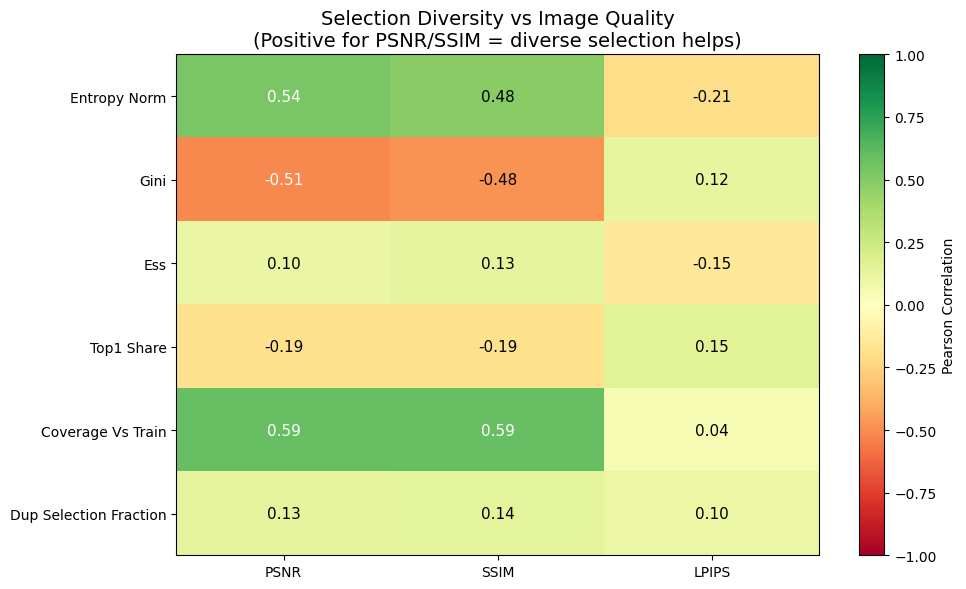

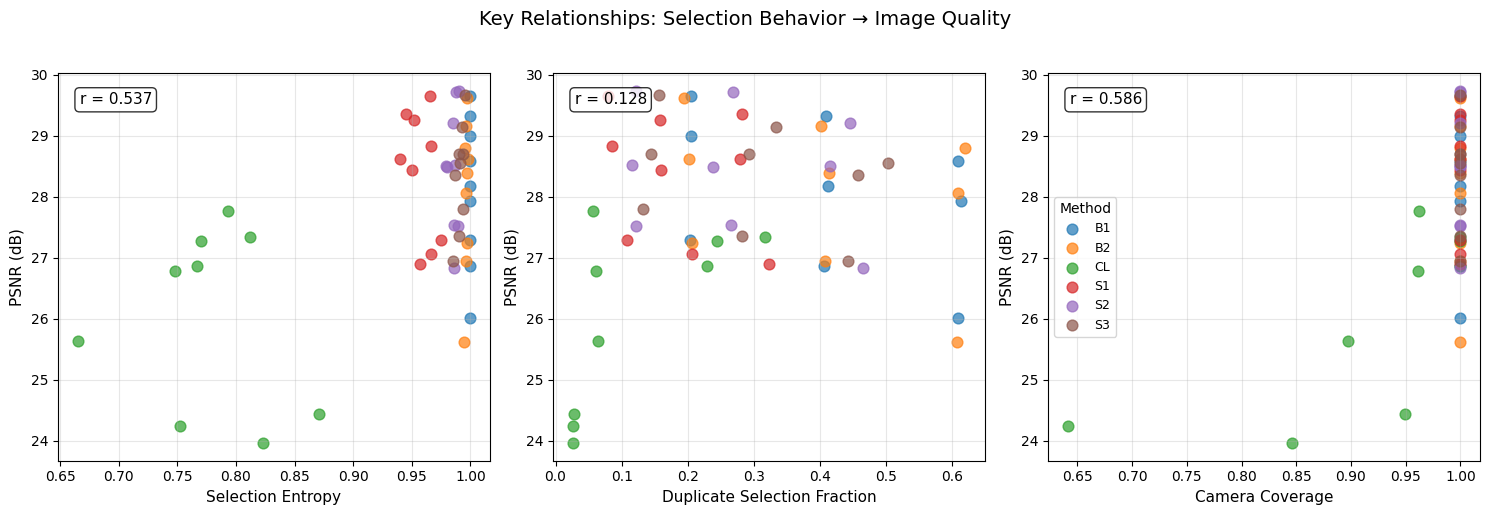

In [19]:
# Join metrics with selection stats
if "run_id" not in metrics_per_run.columns:
    metrics_per_run["run_id"] = metrics_per_run.apply(
        lambda r: f"{r['method']}/{r['scene']}/seed{int(r['seed'])}", axis=1
    )

joined = pd.merge(
    metrics_per_run,
    selection_stats,
    on=["run_id", "method", "base_scene_id", "ratio", "seed"],
    how="left",
    suffixes=("", "_sel")
)

print(f"Joined {len(joined)} runs with selection statistics")

# =========================================================================
# CORRELATION MATRIX: Selection metrics vs Quality metrics
# =========================================================================
selection_cols = ["entropy_norm", "gini", "ess", "top1_share", "coverage_vs_train", "dup_selection_fraction"]
quality_cols = ["mean_psnr", "mean_ssim", "mean_lpips"]

# Filter to columns that exist
selection_cols = [c for c in selection_cols if c in joined.columns]
quality_cols = [c for c in quality_cols if c in joined.columns]

if selection_cols and quality_cols:
    # Compute correlations
    corr_data = joined[selection_cols + quality_cols].dropna()
    
    if len(corr_data) > 3:
        corr_matrix = corr_data.corr()
        
        # Extract just selection vs quality correlations
        corr_subset = corr_matrix.loc[selection_cols, quality_cols]
        
        print("Correlation Matrix: Selection Metrics vs Quality Metrics")
        display(corr_subset.style.background_gradient(cmap="RdYlGn", vmin=-1, vmax=1).format("{:.3f}"))
        
        # Heatmap
        fig, ax = plt.subplots(figsize=(10, 6))
        im = ax.imshow(corr_subset.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
        
        ax.set_xticks(np.arange(len(quality_cols)))
        ax.set_yticks(np.arange(len(selection_cols)))
        ax.set_xticklabels([c.replace("mean_", "").upper() for c in quality_cols])
        ax.set_yticklabels([c.replace("_", " ").title() for c in selection_cols])
        
        # Add correlation values as text
        for i in range(len(selection_cols)):
            for j in range(len(quality_cols)):
                val = corr_subset.values[i, j]
                color = "white" if abs(val) > 0.5 else "black"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=11)
        
        plt.colorbar(im, ax=ax, label="Pearson Correlation")
        ax.set_title("Selection Diversity vs Image Quality\n(Positive for PSNR/SSIM = diverse selection helps)", fontsize=14)
        
        plt.tight_layout()
        savefig("correlation_selection_vs_quality.png")
        plt.show()
        
        # =========================================================================
        # KEY INSIGHT SCATTER PLOTS
        # =========================================================================
        key_pairs = [
            ("entropy_norm", "mean_psnr", "Selection Entropy", "PSNR (dB)"),
            ("dup_selection_fraction", "mean_psnr", "Duplicate Selection Fraction", "PSNR (dB)"),
            ("coverage_vs_train", "mean_psnr", "Camera Coverage", "PSNR (dB)"),
        ]
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        for ax, (sel_col, qual_col, sel_label, qual_label) in zip(axes, key_pairs):
            if sel_col not in joined.columns or qual_col not in joined.columns:
                continue
            
            for method in sorted(joined["method"].unique()):
                method_data = joined[joined["method"] == method]
                ax.scatter(method_data[sel_col], method_data[qual_col], 
                          label=method, alpha=0.7, s=60)
            
            ax.set_xlabel(sel_label, fontsize=11)
            ax.set_ylabel(qual_label, fontsize=11)
            
            # Add correlation annotation
            valid = joined[[sel_col, qual_col]].dropna()
            if len(valid) > 2:
                r = np.corrcoef(valid[sel_col], valid[qual_col])[0, 1]
                ax.annotate(f"r = {r:.3f}", xy=(0.05, 0.95), xycoords="axes fraction",
                           fontsize=11, ha="left", va="top", 
                           bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
            
            ax.grid(alpha=0.3)
        
        axes[-1].legend(title="Method", loc="best", fontsize=9)
        fig.suptitle("Key Relationships: Selection Behavior → Image Quality", fontsize=14, y=1.02)
        
        plt.tight_layout()
        savefig("scatter_selection_vs_quality.png")
        plt.show()
else:
    print("Insufficient columns for correlation analysis")

## 13. Pose Distribution Sanity Check (Optional)

Quick check that camera pose distribution is similar across imbalance ratios (the duplicates share the same pose as the original).

In [20]:
def pose_spread_from_cameras(cams: pd.DataFrame) -> Dict[str, float]:
    if cams is None or len(cams) == 0:
        return {}
    pos = []
    for p in cams["position"].tolist():
        if not isinstance(p, list) or len(p) != 3:
            continue
        pos.append(p)
    if not pos:
        return {}
    X = np.array(pos, dtype=float)
    mu = X.mean(axis=0)
    rg = float(np.sqrt(((X - mu) ** 2).sum(axis=1).mean()))
    C = np.cov((X - mu).T)
    w = np.sort(np.linalg.eigvalsh(C))[::-1]
    return {
        "num_cams": float(X.shape[0]),
        "radius_gyration": rg,
        "pca_eig1": float(w[0]) if len(w) > 0 else float("nan"),
        "pca_eig2": float(w[1]) if len(w) > 1 else float("nan"),
        "pca_eig3": float(w[2]) if len(w) > 2 else float("nan"),
    }


pose_rows = []
# One run per (scene, ratio) is enough because cameras.json is the same across methods (for same dataset)
for (scene, ratio), g in run_registry.groupby(["base_scene_id", "ratio"], dropna=False):
    run_dir = Path(g.iloc[0]["run_dir"])
    cams = load_cameras(run_dir)
    stats = pose_spread_from_cameras(cams) if cams is not None else {}
    pose_rows.append({"base_scene_id": scene, "ratio": ratio, **stats})

pose_spread = pd.DataFrame(pose_rows)
pose_spread_path = NOTEBOOK_OUTPUTS_DIR / "pose_spread.csv"
pose_spread.to_csv(pose_spread_path, index=False)
print("Wrote:", pose_spread_path.resolve())

display(pose_spread)

Wrote: /home/fgrob/gaussian-splatting/notebook_outputs/ablation_imbalanced_sanity_v1_analysis/pose_spread.csv


,base_scene_id,ratio,num_cams,radius_gyration,pca_eig1,pca_eig2,pca_eig3
0,0c5385e84b,20,220.0,1.196316,1.391688,0.033385,0.012633
1,0c5385e84b,40,294.0,1.108925,1.195763,0.028608,0.009541
2,0c5385e84b,60,440.0,0.962459,0.901084,0.020951,0.006403
3,5371eff4f9,20,298.0,1.281211,1.099329,0.512428,0.035271
4,5371eff4f9,40,397.0,1.175158,0.957261,0.398342,0.028881
5,5371eff4f9,60,595.0,1.010402,0.730900,0.271342,0.020390
6,c0f5742640,20,349.0,0.930967,0.714679,0.113543,0.040968
7,c0f5742640,40,465.0,0.891186,0.675009,0.087600,0.033315
8,c0f5742640,60,698.0,0.790730,0.543543,0.059399,0.023208


## 14. Experiment Summary & Key Findings

This section generates a summary table to answer the key experimental questions:

1. **Do smart methods improve over baselines on imbalanced data?**
2. **Does improvement increase with imbalance ratio?**
3. **Do smart methods avoid selecting duplicates?**
4. **Does selection diversity correlate with quality?**

In [21]:
# =========================================================================
# EXPERIMENT SUMMARY TABLE
# =========================================================================

print("=" * 80)
print("IMBALANCED DATASET ABLATION STUDY - SUMMARY")
print("=" * 80)

# 1. Overall performance ranking
print("\n1. OVERALL PERFORMANCE RANKING (by mean PSNR, averaged across all scenes/ratios):")
if len(metrics_per_run) > 0:
    ranking = metrics_per_run.groupby("method")[["mean_psnr", "mean_ssim", "mean_lpips"]].mean()
    ranking = ranking.sort_values("mean_psnr", ascending=False)
    display(ranking.style.format("{:.4f}").background_gradient(subset=["mean_psnr", "mean_ssim"], cmap="Greens")
            .background_gradient(subset=["mean_lpips"], cmap="Reds_r"))

# 2. Method improvement vs baselines
print("\n2. IMPROVEMENT OVER BASELINES:")
if len(improvements_df) > 0:
    imp_summary = improvements_df.groupby(["method", "baseline"])[["delta_psnr", "delta_ssim", "delta_lpips"]].mean()
    display(imp_summary.style.format("{:.4f}").background_gradient(subset=["delta_psnr", "delta_ssim"], cmap="RdYlGn", vmin=-1, vmax=1)
            .background_gradient(subset=["delta_lpips"], cmap="RdYlGn_r", vmin=-0.05, vmax=0.05))

# 3. Duplicate avoidance
print("\n3. DUPLICATE SELECTION BEHAVIOR:")
if len(dup_stats) > 0:
    dup_summary = dup_stats.groupby("method")["dup_fraction"].mean().sort_values()
    print("Average duplicate selection fraction (lower = better at avoiding duplicates):")
    for method, frac in dup_summary.items():
        status = "✓" if frac < 0.15 else "✗"  # Arbitrary threshold
        print(f"  {status} {method}: {frac:.1%}")

# 4. Selection diversity
print("\n4. SELECTION DIVERSITY METRICS:")
if len(selection_stats) > 0:
    div_summary = selection_stats.groupby("method")[["entropy_norm", "gini", "ess", "coverage_vs_train"]].mean()
    div_summary = div_summary.sort_values("entropy_norm", ascending=False)
    display(div_summary.style.format("{:.3f}"))

# 5. Final verdict table
print("\n5. FINAL VERDICT TABLE:")
print("-" * 80)

verdict_rows = []
all_methods_final = sorted(metrics_per_run["method"].unique()) if len(metrics_per_run) > 0 else []

for method in all_methods_final:
    row = {"Method": method}
    
    # Average PSNR
    psnr = metrics_per_run[metrics_per_run["method"] == method]["mean_psnr"].mean()
    row["Avg PSNR"] = f"{psnr:.2f}" if not pd.isna(psnr) else "N/A"
    
    # Improvement vs uniform_random
    if len(improvements_df) > 0:
        imp = improvements_df[
            (improvements_df["method"] == method) & 
            (improvements_df["baseline"] == "uniform_random")
        ]["delta_psnr"].mean()
        if not pd.isna(imp):
            row["vs Uniform"] = f"{imp:+.3f} dB"
        else:
            row["vs Uniform"] = "N/A"
    else:
        row["vs Uniform"] = "N/A"
    
    # Duplicate avoidance
    if len(dup_stats) > 0:
        dup_frac = dup_stats[dup_stats["method"] == method]["dup_fraction"].mean()
        row["Dup Selection"] = f"{dup_frac:.1%}" if not pd.isna(dup_frac) else "N/A"
    else:
        row["Dup Selection"] = "N/A"
    
    # Diversity (entropy)
    if len(selection_stats) > 0:
        ent = selection_stats[selection_stats["method"] == method]["entropy_norm"].mean()
        row["Entropy"] = f"{ent:.3f}" if not pd.isna(ent) else "N/A"
    else:
        row["Entropy"] = "N/A"
    
    verdict_rows.append(row)

if verdict_rows:
    verdict_df = pd.DataFrame(verdict_rows)
    display(verdict_df)

print("\n" + "=" * 80)
print("KEY TAKEAWAYS:")
print("=" * 80)
print("""
• Higher entropy/ESS indicates more diverse view selection
• Lower duplicate selection fraction indicates method recognizes redundancy
• Positive ΔPSNR vs baselines indicates improvement from smart selection
• Methods that avoid duplicates should show improvement at high imbalance ratios
""")

# =========================================================================
# SAVE ALL ARTIFACTS
# =========================================================================
print("\n" + "=" * 80)
print("ARTIFACTS")
print("=" * 80)

artifacts = [
    ("run_registry.csv", run_registry_path),
    ("metrics_per_run.csv", metrics_per_run_path),
    ("aggregated_metrics.csv", aggregated_metrics_path),
    ("selection_summary.csv", selection_summary_path),
    ("selection_stats.csv", selection_stats_path),
]

print("\nWritten to:", NOTEBOOK_OUTPUTS_DIR.resolve())
for name, path in artifacts:
    if path.exists():
        print(f"  ✓ {name}")

# Save joined table
joined_path = NOTEBOOK_OUTPUTS_DIR / "joined_metrics_and_selection.csv"
joined.to_csv(joined_path, index=False)
print(f"  ✓ joined_metrics_and_selection.csv")

# Save improvements table if available
if len(improvements_df) > 0:
    improvements_path = NOTEBOOK_OUTPUTS_DIR / "improvements_vs_baselines.csv"
    improvements_df.to_csv(improvements_path, index=False)
    print(f"  ✓ improvements_vs_baselines.csv")

print("\nFigures saved under the same directory.")

IMBALANCED DATASET ABLATION STUDY - SUMMARY

1. OVERALL PERFORMANCE RANKING (by mean PSNR, averaged across all scenes/ratios):


,mean_psnr,mean_ssim,mean_lpips
method,,,
S2,28.4516,0.9130,0.1965
S1,28.3741,0.9115,0.1980
S3,28.3563,0.9124,0.2010
B1,28.0928,0.9090,0.2090
B2,28.0469,0.9082,0.2089
CL,26.0336,0.8855,0.2236



2. IMPROVEMENT OVER BASELINES:

3. DUPLICATE SELECTION BEHAVIOR:
Average duplicate selection fraction (lower = better at avoiding duplicates):
  ✓ CL: 11.7%
  ✗ S1: 18.6%
  ✗ S2: 27.3%
  ✗ S3: 30.4%
  ✗ B2: 40.7%
  ✗ B1: 40.8%

4. SELECTION DIVERSITY METRICS:


,entropy_norm,gini,ess,coverage_vs_train
method,,,,
B1,1.000,0.007,407.174,1.000
B2,0.996,0.115,388.581,1.000
S3,0.991,0.182,363.395,1.000
S2,0.986,0.229,347.256,1.000
S1,0.958,0.385,246.110,1.000
CL,0.778,0.698,59.134,0.917



5. FINAL VERDICT TABLE:
--------------------------------------------------------------------------------


,Method,Avg PSNR,vs Uniform,Dup Selection,Entropy
0,B1,28.09,N/A,40.8%,1.000
1,B2,28.05,N/A,40.7%,0.996
2,CL,26.03,N/A,11.7%,0.778
3,S1,28.37,N/A,18.6%,0.958
4,S2,28.45,N/A,27.3%,0.986
5,S3,28.36,N/A,30.4%,0.991



KEY TAKEAWAYS:

• Higher entropy/ESS indicates more diverse view selection
• Lower duplicate selection fraction indicates method recognizes redundancy
• Positive ΔPSNR vs baselines indicates improvement from smart selection
• Methods that avoid duplicates should show improvement at high imbalance ratios


ARTIFACTS

Written to: /home/fgrob/gaussian-splatting/notebook_outputs/ablation_imbalanced_sanity_v1_analysis
  ✓ run_registry.csv
  ✓ metrics_per_run.csv
  ✓ aggregated_metrics.csv
  ✓ selection_summary.csv
  ✓ selection_stats.csv
  ✓ joined_metrics_and_selection.csv

Figures saved under the same directory.
